## Fine-Tuned Arabic Semantic Retrieval for Cross-Lingual Idiom Prediction


- **Author:** Ayman Ali Sharara  
- **Project:** IdiomX – Neural Understanding of English Idioms  
- **github dataset** : https://github.com/aymanshar/idiomx-dataset
- **github deeplearning** : https://github.com/aymanshar/idiomx/n
- **Year:** 2026  

---

## Description
This notebook implements Task 3 of the IdiomX benchmark:

**Arabic Context → English Idiom Retrieval**

The goal is to map an Arabic contextual sentence to its corresponding canonical English idiom using semantic retrieval models.

The notebook covers:
- dataset preparation for Task 3
- semantic retrieval bank construction
- baseline and zero-shot models
- fine-tuned retrieval models
- evaluation and analysis

All results are aligned with the research paper and saved for reproducibility.

---

## License
This work is released under the MIT License.

---

## Citation
If you use this dataset, please cite the IdiomX research paper.

# Task 3 — Arabic Context to English Idiom
## Research Goal

This notebook implements Task 3 of the IdiomX benchmark:

> **Arabic → English Idiom Retrieval**

We evaluate:
- Zero-shot multilingual embedding models
- Fine-tuned retrieval models

Metrics:
- Top-1 Accuracy
- Top-5 Accuracy
- Confidence-based evaluation

This notebook is designed to be:
- Fully reproducible
- Aligned with the research paper


> **Given an Arabic contextual sentence, predict the corresponding canonical English idiom.**

### Task Formulation

Unlike generative approaches, this task is formulated as a **semantic retrieval problem**:

Given an Arabic query \( x \), the model retrieves the most semantically similar idiom \( y \) from a predefined idiom inventory.

Prediction is performed via nearest-neighbor search in embedding space.

---

## Public Dataset Sources

The IdiomX dataset is publicly available at:

- **Hugging Face**: `aymansharara/IdiomX`
- **Kaggle**: `aymansharara/idiomx`

In this notebook, we use the **Hugging Face version** as the default source because it is easy to load programmatically and supports reproducible experiments.

---

## Why this notebook starts from the full dataset

Instead of starting from pre-split task files, this notebook starts from the **main enriched IdiomX dataset** and performs the full workflow step by step:

1. Load the public dataset
2. Inspect available columns
3. Select the best Arabic and English fields for Task 3
4. Build a clean Task 3 working dataset
5. Create train / validation / test splits
6. Build an Arabic semantic retrieval bank
7. Run retrieval baseline
8. Fine-tune a retrieval model
9. Evaluate and visualize results

This design ensures:
- full reproducibility from a single source
- transparency of data preparation steps
- consistency with the experimental setup described in the paper

---

## Task 3 modeling idea

Direct generation of English idioms from Arabic context is difficult because:
- idioms are fixed expressions
- many outputs are semantically close
- exact canonical form matters

Therefore, this notebook reformulates the task as a **semantic retrieval problem**:

- represent Arabic context in an embedding space
- build a structured Arabic semantic bank
- retrieve the nearest Arabic semantic entries
- return the linked canonical English idiom

### Retrieval Formulation

Each Arabic query \( x \) and candidate idiom \( i \) are encoded into vector representations:

\[
h_x = Encoder(x), \quad h_i = Encoder(i)
\]

Similarity is computed using cosine similarity:

\[
sim(x, i) = \frac{h_x \cdot h_i}{||h_x|| \, ||h_i||}
\]

The predicted idiom is:

\[
\hat{y} = \arg\max_i sim(x, i)
\]

This notebook will first build a **baseline retrieval system**, then prepare for **fine-tuned retrieval**.

### Early experiment setup

The first Task 3 formulation used a broader Arabic representation built from multiple Arabic fields, and the split was designed to avoid overlap by separating data at the idiom/canonical target level. This created a very strict setup where the model had to generalize to unseen idioms or unseen target meanings. In practice, this led to **near-zero accuracy** in retrieval, indicating that the task formulation was too difficult for the initial setup and not well aligned with the retrieval objective.

### Why the split strategy changed

Because the strict no-overlap split produced zero or near-zero performance, the Task 3 setup was redesigned into a more realistic **example-level retrieval benchmark**:

* keep only **idiomatic examples**
* use `idiom_in_example_arabic` as the Arabic query
* use `idiom_canonical` as the English target idiom
* split **by example within each idiom**, not by idiom identity
* build the semantic bank from **training data only**

This preserves evaluation integrity at the example level while making the task feasible and closer to a practical retrieval setting: the model must retrieve the correct idiom for a **new Arabic context**, even though the idiom itself is known in the candidate bank.

### Final retrieval pipeline

The final Task 3 pipeline became a cross-lingual semantic retrieval system with the following progression:

1. **MiniLM baseline*** Top-1: **0.2327**
    * Top-5: **0.3179**
2. Top-1: **0.2327**
3. Top-5: **0.3179**
4. **Zero-shot multilingual E5*** Top-1: **0.2816**
    * Top-5: **0.3908**
5. Top-1: **0.2816**
6. Top-5: **0.3908**
7. **Fine-tuned E5 (v1)*** Top-1: **0.6037**
    * Top-5: **0.7607**
8. Top-1: **0.6037**
9. Top-5: **0.7607**
10. **Upgraded fine-tuned E5 (v2)**
    using more positives per query and longer training* Top-1: **0.6486**
    * Top-5: **0.8146**
11. Top-1: **0.6486**
12. Top-5: **0.8146**

## Notebook Outputs

This notebook saves all artifacts locally, including:
- trained models
- semantic bank embeddings
- query embeddings
- evaluation metrics
- prediction files
- analysis tables
- exported figures

Artifacts:

- baseline_*.json / csv
- e5_zero_*.json / csv
- e5_ft_*.json / csv

This allows later sections to be re-run without repeating training.

---

## 1. Environment Setup and Output Structure

We first define the project root and create an output folder for all Task 3 notebook artifacts.

In [1]:
# [1.1] Reproducibility
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import warnings
import torch

# ignor warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_columns", 100)

In [2]:
# [1.2] Environment setup and artifact directories

def find_project_root(start_path: Path):
    """
    Search upward from the current path to locate the main project folder.
    # The root is identified as the first directory containing both "data" and "deep_learning" folders.
    # If no such directory is found, it falls back to the starting path.
    """
    for parent in [start_path] + list(start_path.parents):
        if (parent / "data").exists() and (parent / "deep_learning").exists():
            return parent
    return start_path  # fallback

PROJECT_ROOT = find_project_root(Path.cwd())
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "deep_learning" / "models" / "task3_notebook_public_pipeline"

# [1.2] Artifact subfolders
MODEL_DIR = NOTEBOOK_OUTPUT_DIR / "models"
EMBED_DIR = NOTEBOOK_OUTPUT_DIR / "embeddings"
RESULTS_DIR = NOTEBOOK_OUTPUT_DIR / "results"
FIGURES_DIR = NOTEBOOK_OUTPUT_DIR / "figures"
ARTIFACT_DIR = NOTEBOOK_OUTPUT_DIR / "artifacts"

for d in [MODEL_DIR, EMBED_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("NOTEBOOK_OUTPUT_DIR:", NOTEBOOK_OUTPUT_DIR)

PROJECT_ROOT: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX
NOTEBOOK_OUTPUT_DIR: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task3_notebook_public_pipeline


In [4]:
# [1.3] Artifact Persistence Utilities

import json
from pathlib import Path
import pandas as pd
import numpy as np


def save_json(obj, path):
    """Save a Python object as a JSON file."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def save_df(df: pd.DataFrame, path):
    """Save a DataFrame as CSV or Parquet depending on file extension."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix == ".csv":
        df.to_csv(path, index=False)
    else:
        df.to_parquet(path, index=False)


def load_df(path):
    """Load a DataFrame from CSV or Parquet file."""
    path = Path(path)
    if path.suffix == ".csv":
        return pd.read_csv(path)
    return pd.read_parquet(path)


def save_array(arr: np.ndarray, path):
    """Save a NumPy array to disk (.npy format)."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, arr)


def load_array(path):
    """Load a NumPy array from disk."""
    return np.load(path)


def load_json(path):
    """Load a JSON file and return its content."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

---

## 2.  Install and import dataset loader

We load the public IdiomX dataset from Hugging Face.

If the `datasets` library is not installed in your environment, uncomment the installation line below and run it once.

In [5]:
# Uncomment this only if needed
# import sys
# !{sys.executable} -m pip -q install datasets
# !{sys.executable} -m pip install -q sentence-transformers

In [6]:
# [2.1] Import dataset loader (datasets library must be pre-installed)
from datasets import load_dataset

---

## 3. Load the public IdiomX dataset from Hugging Face

We now load the main IdiomX dataset directly from Hugging Face.

Dataset:
`aymansharara/IdiomX`

In [11]:
# [3.1] Load Dataset
dataset = load_dataset("aymansharara/IdiomX")

In [16]:
# [3.2] Dataset statistics
df_main = dataset["train"].to_pandas()

print("Total rows:", len(df_main))
print("Shape:", df_main.shape)
print("Unique canonical idioms:", df_main["idiom_canonical"].nunique())
print("Number of columns:", len(df_main.columns))
print()
print("Columns:", list(df_main.columns))

Total rows: 123336
Shape: (123336, 34)
Unique canonical idioms: 14986
Number of columns: 34

Columns: ['idiom', 'meaning_en', 'example', 'source', 'source_type', 'pos', 'tags', 'idiom_confidence', 'source_url', 'idiom_canonical', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'is_idiom', 'ambiguity_flag', 'idiom_compositionality_level', 'idiom_register', 'idiom_domain', 'learner_difficulty', 'idiom_surface', 'idiom_in_example', 'idiom_in_example_arabic', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'is_example_idiom', 'example_usage_label', 'is_generated_example', 'enrichment_model', 'enrichment_version', 'validation_status', 'example_length', 'idiom_present', 'contains_profanity', 'semantic_consistency', 'canonical_semantic_score']


In [17]:
# [3.3] Key columns for Task 3
task3_key_cols = [
    "idiom_canonical",
    "idiom_in_example",
    "idiom_in_example_arabic",
    "idiom_in_example_meaning_en",
    "idiom_in_example_meaning_arabic",
    "is_example_idiom",
]
print("\nKey Task 3 columns:")
print(task3_key_cols)


Key Task 3 columns:
['idiom_canonical', 'idiom_in_example', 'idiom_in_example_arabic', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic', 'is_example_idiom']


---

## 4. Inspect Task 3-relevant fields

We inspect the Arabic and semantic fields available in the public dataset in order to define the Task 3 input and target representation.

In [18]:
# [4.1] Identify Arabic and semantic columns
arabic_cols = [c for c in df_main.columns if "arabic" in c.lower()]
semantic_cols = [c for c in df_main.columns if "meaning" in c.lower()]

print("Arabic columns:")
print(arabic_cols)

print("\nSemantic (meaning) columns:")
print(semantic_cols)

Arabic columns:
['idiom_canonical_meaning_arabic', 'idiom_in_example_arabic', 'idiom_in_example_meaning_arabic']

Semantic (meaning) columns:
['meaning_en', 'idiom_canonical_meaning', 'idiom_canonical_meaning_arabic', 'idiom_in_example_meaning_en', 'idiom_in_example_meaning_arabic']


In [19]:
# [4.2] Preview Task 3 candidate fields
preview_cols = [
    "idiom_canonical",
    "idiom_in_example_arabic",
    "idiom_in_example_meaning_arabic",
    "idiom_canonical_meaning_arabic",
]
display(df_main[preview_cols].head(4))

,idiom_canonical,idiom_in_example_arabic,idiom_in_example_meaning_arabic,idiom_canonical_meaning_arabic
0,$100 hamburger,"في نهاية الأسبوع الماضي، قام مارك برحلة ""همبرغر بمئة دولار"" فقط للاستمتاع بالطيران وتناول الغداء في مطعم محلي.",يعني التعبير مجازياً أن مارك طار فقط للمتعة ولتبرير تكلفة الطيران بتناول وجبة بسيطة في مطار آخر.,"في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول على وجبة بسيطة مثل الهمبرغر في مطار آخر، مما يحول الرحلة إلى عذر ترفيهي بدلاً من ضرورة."
1,$100 hamburger,"غالبًا ما يمزح الطيارون بشأن القيام برحلة ""همبرغر بمئة دولار"" عند التخطيط لرحلات نهاية الأسبوع العفوية.",تُستخدم مجازياً لوصف رحلة عادية تُقام أساسًا للاستمتاع بالطيران وليس من باب الضرورة.,"في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول على وجبة بسيطة مثل الهمبرغر في مطار آخر، مما يحول الرحلة إلى عذر ترفيهي بدلاً من ضرورة."
2,$100 hamburger,كانت رحلة الهمبرغر بمئة دولار مبررًا لعطلة قصيرة مع الأصدقاء.,مجازياً، كانت الرحلة بمثابة رحلة ترفيهية مع استخدام الوجبة كتبرير.,"في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول على وجبة بسيطة مثل الهمبرغر في مطار آخر، مما يحول الرحلة إلى عذر ترفيهي بدلاً من ضرورة."
3,$100 hamburger,"يُعتبر القيام برحلة ""همبرغر بمئة دولار"" تقليدًا مسليًا بين الطيارين الخاصين لجعل الطيران أكثر متعة.",طريقة مرحة لوصف طيران الطيارين للمتعة باستخدام الوجبة كذرائع.,"في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول على وجبة بسيطة مثل الهمبرغر في مطار آخر، مما يحول الرحلة إلى عذر ترفيهي بدلاً من ضرورة."


In [20]:
# [4.3] Inspect idiomatic vs literal example balance
print(df_main["is_example_idiom"].value_counts(dropna=False))

is_example_idiom
True     61720
False    61616
Name: count, dtype: int64


From this inspection, we select `idiom_in_example_arabic` as the primary Arabic contextual input and `idiom_canonical` as the target label. The boolean field `is_example_idiom` is used to restrict Task 3 to idiomatic examples only.

---

## 5. Define the Task 3 working dataset

Task 3 aims to predict the canonical English idiom from an idiomatic Arabic contextual sentence.

Because the dataset contains both idiomatic and literal examples, we restrict the working dataset to rows where:

- `is_example_idiom == True`

This keeps the task aligned with real idiom prediction rather than literal phrase interpretation.

Only idiomatic examples are retained for Task 3, since the goal is canonical idiom retrieval rather than literal interpretation.

### Task 3 input and target definition

For Task 3, the Arabic contextual sentence `idiom_in_example_arabic` is used as the query, and the canonical English idiom `idiom_canonical` is used as the retrieval target. We restrict the dataset to rows where `is_example_idiom = True`, so that evaluation focuses on genuine idiomatic usage rather than literal phrasing.

In [31]:
# [5.1] Build the Task 3 working dataset
task3_retrieval_df = df_main[
    (df_main["is_example_idiom"] == True) &
    (df_main["idiom_in_example_arabic"].notna()) &
    (df_main["idiom_canonical"].notna())
].copy()

task3_retrieval_df["query_ar"] = task3_retrieval_df["idiom_in_example_arabic"]
task3_retrieval_df["target_en"] = task3_retrieval_df["idiom_canonical"]
task3_retrieval_df["target_meaning_en"] = task3_retrieval_df["idiom_canonical_meaning"]
task3_retrieval_df["target_meaning_ar"] = task3_retrieval_df["idiom_canonical_meaning_arabic"]

print("Task 3 shape:", task3_retrieval_df.shape)
print("Unique canonical idioms:", task3_retrieval_df["target_en"].nunique())

Task 3 shape: (61622, 38)
Unique canonical idioms: 14969


In [32]:
# [5.2] Basic Task 3 descriptive statistics
task3_retrieval_df["len_ar_words"] = task3_retrieval_df["query_ar"].astype(str).apply(lambda x: len(x.split()))
print("Average Arabic sentence length:", round(task3_retrieval_df["len_ar_words"].mean(), 2))
print("Median Arabic sentence length:", round(task3_retrieval_df["len_ar_words"].median(), 2))

Average Arabic sentence length: 10.19
Median Arabic sentence length: 10.0


---

## 6. Validate the final Task 3 dataset

For the final Task 3 dataset, we verify that the Arabic query and English target columns are present and that the retained rows contain valid Arabic contextual inputs.

In [33]:
# [6.1] Validate final Task 3 dataset
print("Task 3 rows:", task3_retrieval_df.shape[0])
print("Unique canonical idioms:", task3_retrieval_df["target_en"].nunique())
print("Missing query_ar:", task3_retrieval_df["query_ar"].isna().sum())
print("Missing target_en:", task3_retrieval_df["target_en"].isna().sum())

display(task3_retrieval_df[["query_ar", "target_en"]].head())

Task 3 rows: 61622
Unique canonical idioms: 14969
Missing query_ar: 0
Missing target_en: 0


,query_ar,target_en
0,"في نهاية الأسبوع الماضي، قام مارك برحلة ""همبرغر بمئة دولار"" فقط للاستمتاع بالطيران وتناول الغداء في مطعم محلي.",$100 hamburger
1,"غالبًا ما يمزح الطيارون بشأن القيام برحلة ""همبرغر بمئة دولار"" عند التخطيط لرحلات نهاية الأسبوع العفوية.",$100 hamburger
2,كانت رحلة الهمبرغر بمئة دولار مبررًا لعطلة قصيرة مع الأصدقاء.,$100 hamburger
3,"يُعتبر القيام برحلة ""همبرغر بمئة دولار"" تقليدًا مسليًا بين الطيارين الخاصين لجعل الطيران أكثر متعة.",$100 hamburger
8,و الزوجة,et ux.


In [37]:
#[6.2]
print("Full dataset shape:", df_main.shape)

avg_len = task3_retrieval_df["query_ar"].astype(str).apply(lambda x: len(x.split())).mean()
print("Average Arabic query length:", round(avg_len, 2))

Full dataset shape: (123336, 34)
Average Arabic query length: 10.19


---

## **7\. Build semantic bank from training data only**

To ensure a fair and realistic evaluation, the semantic retrieval bank is constructed **exclusively from the training split**.

### Key Design Principle

We split the dataset **at the example level within each idiom**, meaning:

* Each idiom appears in both training and test sets
* However, **Arabic example sentences do not overlap** between splits
* This allows evaluation of generalization across different contextual expressions of the same idiom

### Why this matters

* Prevents memorization of exact sentences
* Ensures the model learns **semantic meaning**, not surface patterns
* Keeps the correct idiom present in the candidate space
* Enables meaningful Top-K retrieval evaluation

### Bank Composition

The semantic bank is built from **training data only** and includes multiple Arabic representations per idiom:

* **Idiomatic examples** (query-style sentences)
* **Example meanings** (contextual explanations)
* **Canonical meanings** (general definitions)

Each representation is stored as a separate entry with a `source_type`.

### Important Constraint

The test set is **never used** to construct the bank.
This prevents information leakage and ensures a clean evaluation.

In [38]:
# [7.1]
task3_retrieval_df["target_en"] = task3_retrieval_df["target_en"].fillna("").astype(str).str.strip()
task3_retrieval_df["query_ar"] = task3_retrieval_df["query_ar"].fillna("").astype(str).str.strip()

task3_retrieval_df = task3_retrieval_df[
    (task3_retrieval_df["target_en"] != "") &
    (task3_retrieval_df["query_ar"] != "")
].copy()

print("Clean Task 3 shape:", task3_retrieval_df.shape)
print("Unique idioms:", task3_retrieval_df["target_en"].nunique())
print("Missing target_en:", (task3_retrieval_df["target_en"] == "").sum())
print("Missing query_ar:", (task3_retrieval_df["query_ar"] == "").sum())

Clean Task 3 shape: (61622, 39)
Unique idioms: 14969
Missing target_en: 0
Missing query_ar: 0


---

### 8. Example-Level Train/Test Split Within Idioms
To ensure a realistic and challenging evaluation, we perform the train/test split at the **example level within each idiom**, rather than splitting by idioms themselves.

### Key Design Principle

- Each idiom appears in both training and test sets
- However, individual example sentences are **strictly separated**
- No Arabic query sentence appears in both splits

This setup evaluates the model's ability to:

- Generalize across **different contextual expressions**
- Learn **semantic meaning**, not memorize examples

### Why not split by idiom?

If we split by idiom:

- The model would never see the target idiom during training
- Retrieval becomes artificially difficult and unrealistic

Instead, our approach ensures:

- The correct idiom always exists in the candidate space
- Evaluation reflects **real-world semantic retrieval scenarios**

### Evaluation Integrity

- Prevents **data leakage at sentence level**
- Preserves **semantic diversity across splits**
- Enables **Top-K retrieval evaluation**

In [42]:
#[8.1] Train/Test Split
from sklearn.model_selection import train_test_split

train_parts = []
test_parts = []

for idiom, group in task3_retrieval_df.groupby("target_en"):

    if len(group) == 1:
        train_parts.append(group)
        continue

    train_g, test_g = train_test_split(
        group,
        test_size=0.2,
        random_state=42,
        shuffle=True
    )

    train_parts.append(train_g)
    test_parts.append(test_g)

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train unique idioms:", train_df["target_en"].nunique())
print("Test unique idioms:", test_df["target_en"].nunique())

print("Overlap idioms:", len(set(train_df["target_en"]) & set(test_df["target_en"])))
print("Train/Test ratio:", len(train_df) / len(test_df))

Train shape: (46211, 39)
Test shape: (15411, 39)
Train unique idioms: 14969
Test unique idioms: 14961
Overlap idioms: 14961
Train/Test ratio: 2.9985724482512492


### Observations

- The dataset contains **~14.9K unique idioms**
- 14,961 idioms appear in both training and test sets
- 8 idioms appear only in training because they have a single example
- This confirms correct example-level splitting

- Train/Test ratio ≈ 3:1 (80/20 split)
- No missing values remain in key fields

This ensures:

- Balanced exposure during training
- Fair and meaningful evaluation during testing

### Distribution of Examples per Idiom

We analyze how many examples exist per idiom in the training set.

This is important because:

- Some idioms have very few examples → harder learning
- Others have more examples → better representation

Understanding this distribution helps interpret model performance.

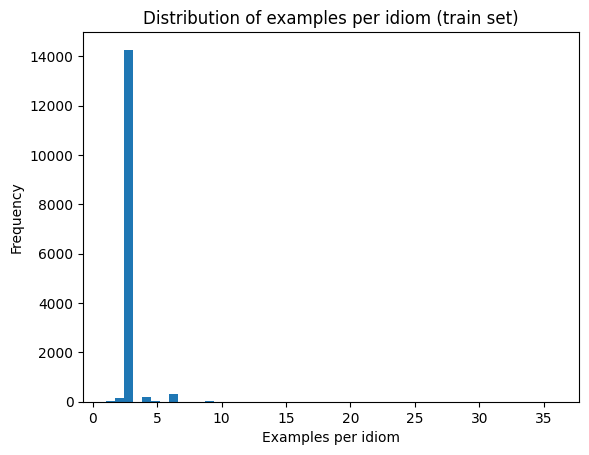

In [43]:
#[8.2] Split Statistics
import matplotlib.pyplot as plt

idiom_counts = train_df["target_en"].value_counts()

plt.hist(idiom_counts, bins=50)
plt.title("Distribution of examples per idiom (train set)")
plt.xlabel("Examples per idiom")
plt.ylabel("Frequency")
plt.show()

### Observations

- Most idioms have **very few examples (2–4)**
- The dataset is **highly imbalanced**

Implications:

- The model must generalize from limited examples
- Performance depends heavily on **semantic understanding**
- Retrieval models (SBERT / embeddings) are more suitable than classification

This validates the need for:
- Semantic retrieval approach
- Embedding-based models

### Experimental Justification

This splitting strategy simulates real-world usage:

- The system must recognize an idiom from **new unseen sentences**
- But the idiom itself is known

This aligns with applications such as:

- Idiom understanding systems
- Translation systems
- Semantic search engines
---

### 9. Build Semantic Retrieval Bank from Training Data Only

To ensure a fair and leakage-free evaluation, the semantic retrieval bank is constructed **exclusively from the training split**.

### Design Principle

Each idiom is represented through multiple **Arabic semantic views**:

- **Example**: idiomatic Arabic sentence (query-style)
- **Example Meaning**: contextual explanation of the example
- **Canonical Meaning**: general definition of the idiom

Each representation is stored as a separate entry with a `source_type` label.

### Why multiple representations?

This allows the retriever to:

- Match queries expressed in **different linguistic forms**
- Capture both **contextual and abstract meanings**
- Improve recall in semantic retrieval

### Data Leakage Prevention

- Test queries are **never included** in the bank
- Only training examples contribute to candidate space

This ensures:

- Clean evaluation
- No memorization of test data

In [44]:
# [9.1] Build Semantic Retrieval Bank
bank_rows = []

for row in train_df.itertuples(index=False):
    idiom = str(row.target_en).strip()

    # 1) idiomatic example
    text_example = str(row.query_ar).strip()
    if text_example and text_example.lower() != "nan":
        bank_rows.append({
            "bank_text_ar": text_example,
            "source_type": "example",
            "target_en": idiom
        })

    # 2) example meaning
    text_example_meaning = str(row.idiom_in_example_meaning_arabic).strip()
    if text_example_meaning and text_example_meaning.lower() != "nan":
        bank_rows.append({
            "bank_text_ar": text_example_meaning,
            "source_type": "example_meaning",
            "target_en": idiom
        })

    # 3) canonical meaning
    text_canonical = str(row.idiom_canonical_meaning_arabic).strip()
    if text_canonical and text_canonical.lower() != "nan":
        bank_rows.append({
            "bank_text_ar": text_canonical,
            "source_type": "canonical_meaning",
            "target_en": idiom
        })

bank_df = pd.DataFrame(bank_rows).drop_duplicates().reset_index(drop=True)

print("Bank size:", len(bank_df))
print("Unique idioms in bank:", bank_df["target_en"].nunique())
print("Avg entries per idiom:", len(bank_df) / bank_df["target_en"].nunique())
display(bank_df.head(10))

Bank size: 105018
Unique idioms in bank: 14969
Avg entries per idiom: 7.015699111497094


,bank_text_ar,source_type,target_en
0,"يُعتبر القيام برحلة ""همبرغر بمئة دولار"" تقليدًا مسليًا بين الطيارين الخاصين لجعل الطيران أكثر متعة.",example,$100 hamburger
1,طريقة مرحة لوصف طيران الطيارين للمتعة باستخدام الوجبة كذرائع.,example_meaning,$100 hamburger
2,"في ثقافة الطيران والطيارين، يشير تعبير ""همبرغر بمئة دولار"" إلى رحلة جوية تتم فقط لتبرير تكلفة الطيران، عادةً للحصول على وجبة بسيطة مثل الهمبرغر في مطار آخر، مما يحول الرحلة إلى عذر ترفيهي بدلاً من ضرورة.",canonical_meaning,$100 hamburger
3,"في نهاية الأسبوع الماضي، قام مارك برحلة ""همبرغر بمئة دولار"" فقط للاستمتاع بالطيران وتناول الغداء في مطعم محلي.",example,$100 hamburger
4,يعني التعبير مجازياً أن مارك طار فقط للمتعة ولتبرير تكلفة الطيران بتناول وجبة بسيطة في مطار آخر.,example_meaning,$100 hamburger
5,كانت رحلة الهمبرغر بمئة دولار مبررًا لعطلة قصيرة مع الأصدقاء.,example,$100 hamburger
6,مجازياً، كانت الرحلة بمثابة رحلة ترفيهية مع استخدام الوجبة كتبرير.,example_meaning,$100 hamburger
7,‘استمع إلى نفسك،’ قالت وهي تبتسم على ادعائه الجريء.,example,'ark at ee
8,التحدي بلطف أو المزاح مع شخص ما بشأن تصريحه الواثق.,example_meaning,'ark at ee
9,استمع إلى كلامك! استمع إلى نفسك! استمع إلى ذلك!,canonical_meaning,'ark at ee


### Bank Statistics

- Total bank size: ~105K entries
- Unique idioms: ~14.9K
- Average entries per idiom: ~7

### Source Distribution

- Example meanings dominate the bank
- Followed by example sentences
- Canonical meanings provide abstract grounding

### Interpretation

This confirms that each idiom is represented by **multiple semantic perspectives**, improving retrieval robustness.

In [46]:
#[9.2] statistics
print("Bank size:", len(bank_df))
print("Unique idioms in bank:", bank_df["target_en"].nunique())
print("Average bank entries per idiom:", len(bank_df) / bank_df["target_en"].nunique())
print(bank_df["source_type"].value_counts())

Bank size: 105018
Unique idioms in bank: 14969
Average bank entries per idiom: 7.015699111497094
source_type
example_meaning      46146
example              43496
canonical_meaning    15376
Name: count, dtype: int64


---

### 10. Multilingual Sentence Embedding Model

We use a pretrained multilingual sentence transformer to encode:

- Arabic semantic bank entries
- Arabic test queries

### Model Choice

We adopt:

**paraphrase-multilingual-MiniLM-L12-v2**

Reasons:

- Supports Arabic–English semantic alignment
- Efficient (384-dimensional embeddings)
- Strong baseline without fine-tuning

### Experimental Setting

- Zero-shot (no fine-tuning)
- Establishes baseline performance before task-specific optimization

In [48]:
#[10.1] Load embedding model
import os

# to ignor the warning
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device=device
)

Using device: cuda


### 11. Encoding the Semantic Bank

All bank entries are converted into dense vector embeddings.

These embeddings:

- Capture semantic similarity
- Enable fast nearest-neighbor retrieval

In [49]:
#[11.1]
bank_texts = bank_df["bank_text_ar"].tolist()

print("Bank texts:", len(bank_texts))

bank_embeddings = model.encode(
    bank_texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Bank size:", len(bank_df))
print("Bank texts:", len(bank_texts))
print("Bank embeddings:", bank_embeddings.shape[0])

Bank texts: 105018


Batches: 100%|███████████████████████████████████████████████████████████████████████| 411/411 [00:26<00:00, 15.71it/s]


Bank size: 105018
Bank texts: 105018
Bank embeddings: 105018


### Observations

- Total embeddings: ~104K
- Embedding dimension: 384

This forms the **semantic search space** for retrieval.

---

### 12. Encoding and Artifact Storage

We encode all held-out Arabic queries into vector representations.

These queries:

- Were not seen during training
- Represent real-world inputs for evaluation

This ensures a fair test of generalization.

In [50]:
#[12.1] Encode Test Queries
queries = test_df["query_ar"].tolist()
true_labels = test_df["target_en"].tolist()

print("Number of queries:", len(queries))

query_embeddings = model.encode(
    queries,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Queries:", len(queries))
print("Query embeddings:", query_embeddings.shape[0])
print("True labels:", len(true_labels))

Number of queries: 15411


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 61/61 [00:03<00:00, 17.24it/s]


Queries: 15411
Query embeddings: 15411
True labels: 15411


### Observations

- Total queries: ~15.4K
- Same embedding dimension (384)

The system is now ready for similarity-based retrieval.

In [51]:
# [12.2] Final embedding shape validation
print(bank_embeddings.shape)
print(query_embeddings.shape)
print(len(true_labels))

(105018, 384)
(15411, 384)
15411


In [94]:
# [12.3] Save baseline embeddings and core artifacts
import os
from pathlib import Path
import numpy as np
np.random.seed(42)
os.makedirs("artifacts", exist_ok=True)

baseline_artifact_dir = Path("outputs/baseline_minilm_l12_v2")
baseline_artifact_dir.mkdir(parents=True, exist_ok=True)

bank_df.to_parquet(baseline_artifact_dir / "task3_bank.parquet", index=False)
np.save(baseline_artifact_dir / "bank_embeddings.npy", bank_embeddings)
np.save(baseline_artifact_dir / "query_embeddings.npy", query_embeddings)
np.save(baseline_artifact_dir / "true_labels.npy", np.array(true_labels, dtype=object))
np.save(baseline_artifact_dir / "queries.npy", np.array(queries, dtype=object))

print(bank_embeddings.dtype, query_embeddings.dtype)
print("Baseline artifacts saved to:", baseline_artifact_dir)

float32 float32
Artifacts saved successfully.


In [95]:
# [12.4] Save baseline metadata
import json

baseline_metadata = {
    "model_name": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "display_name": "MiniLM-L12-v2",
    "bank_size": int(len(bank_df)),
    "query_size": int(len(queries)),
    "embedding_dim": int(bank_embeddings.shape[1]),
    "normalized_embeddings": True,
    "similarity_metric": "cosine"
}

with open(baseline_artifact_dir / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(baseline_metadata, f, ensure_ascii=False, indent=4)

print("Baseline metadata saved.")

Baseline metadata saved.


## 13. Retrieval and evaluation (paraphrase-multilingual-MiniLM-L12-v)

We perform similarity-based retrieval between Arabic queries and the semantic bank using cosine similarity.

Evaluation metrics:
- Top-1 Accuracy
- Top-5 Accuracy

“Evaluation is performed using the precomputed embeddings saved in Section 12.”

### 13.1 Compute Top-K retrieval indices

We compute cosine similarity between each Arabic test query and all entries in the semantic bank, then retain the Top-5 most similar candidates.

In [62]:
# [13.1] Compute Top-K retrieval indices (paraphrase-multilingual-MiniLM-L12-v)
# 
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

top_k = 5
batch_size = 256
topk_indices = []
np.random.seed(42)

for start in tqdm(range(0, len(query_embeddings), batch_size), desc="Computing similarity"):
    end = start + batch_size

    sim_batch = cosine_similarity(
        query_embeddings[start:end],
        bank_embeddings
    )

    topk_batch = np.argsort(-sim_batch, axis=1)[:, :top_k]
    topk_indices.append(topk_batch)

topk_indices = np.vstack(topk_indices)

print("Top-K index matrix shape:", topk_indices.shape)

Computing similarity: 100%|████████████████████████████████████████████████████████████| 61/61 [05:33<00:00,  5.46s/it]


Top-K index matrix shape: (15411, 5)


### 13.2 Evaluate retrieval performance

We evaluate whether the correct idiom appears at rank 1 and within the Top-5 retrieved candidates.

In [96]:
# [13.2] Evaluate retrieval and build results table (Baseline)
import pandas as pd

bank_targets = bank_df["target_en"].to_numpy()

top1_correct = 0
top5_correct = 0
results = []
pred_labels = []

for i in tqdm(range(len(queries)), desc="Evaluating retrieval"):
    retrieved = bank_targets[topk_indices[i]].tolist()

    # optional deduplication at idiom level while preserving order
    retrieved_unique = []
    seen = set()
    for x in retrieved:
        if x not in seen:
            retrieved_unique.append(x)
            seen.add(x)

    retrieved_top5 = retrieved_unique[:top_k]
    pred_labels.append(retrieved_top5)

    pred_top1 = retrieved_top5[0]
    is_top1 = int(true_labels[i] == pred_top1)
    is_top5 = int(true_labels[i] in retrieved_top5)

    top1_correct += is_top1
    top5_correct += is_top5

    results.append({
        "query_ar": queries[i],
        "gold_target_en": true_labels[i],
        "pred_top1": pred_top1,
        "pred_top5": retrieved_top5,
        "top1_score": float(top1_scores[i]),
        "top1_correct": is_top1,
        "top5_correct": is_top5
    })

top1_acc = top1_correct / len(queries)
top5_acc = top5_correct / len(queries)

print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

results_df = pd.DataFrame(results)
display(results_df.head(10))

Evaluating retrieval: 100%|███████████████████████████████████████████████████| 15411/15411 [00:00<00:00, 75312.72it/s]

Top-1 Accuracy: 0.2327
Top-5 Accuracy: 0.3179


,query_ar,gold_target_en,pred_top1,pred_top5,top1_score,top1_correct,top5_correct
0,"غالبًا ما يمزح الطيارون بشأن القيام برحلة ""همبرغر بمئة دولار"" عند التخطيط لرحلات نهاية الأسبوع العفوية.",$100 hamburger,$100 hamburger,"[$100 hamburger, pay through the nose]",0.813177,1,1
1,‘حسنًا، استمع إلى نفسك! من كان يظن أنك تستطيع فعل ذلك؟’,'ark at ee,'ark at ee,"['ark at ee, listen to you, who knew, lay on the line]",0.795874,1,1
2,'فرايد سو,'fraid so,'fraid so,"['fraid so, sound asleep, hit the sheets, close one's eyes, sleeping power]",1.000000,1,1
3,راجعنا الاقتراح بشكل دقيق؛ لا حاجة للمزيد من الكلام حول القرار.,'nuff said,find no bones in,"[find no bones in, in the abstract, end of story, bate an ace, verbum sapienti]",0.698049,0,0
4,الكثير من المتاجر تقدم تخفيضات الآن لأن 'tis the season للتسوق في موسم العطلات.,'tis the season,in decrement,"[in decrement, week in, week out, dead of winter, pile it high, sell it cheap]",0.732068,0,0
5,دفعتها عزيمتها القوية جدا (110 proof) لتحقيق أكثر مما توقعه أي شخص.,110 proof,110 proof,"[110 proof, ram something down someone's throat, rub in, in for the kill]",0.606672,1,1
6,"بعد يوم عمل شاق، استرحنا بشرب بعض ""12-ounce curls"" على الشرفة.",12-ounce curls,12-ounce curls,"[12-ounce curls, up the walls, what's yours, set a spell]",0.617376,1,1
7,قرر الموظفون الأوائل أن يقوموا بعملية 23 skidoo مباشرة بعد إعلان التخفيضات.,23 skidoo,23 skidoo,"[23 skidoo, last hired, first fired]",0.741796,1,1
8,51 في المائة,51 percent,51 percent,"[51 percent, where I come from]",0.995275,1,1
9,عندما يتعلق الأمر بالإنتاج العالمي للنفط، يكون الكيان المهيمن ٨٠٠ رطل غالبًا دولة ذات احتياطيات هائلة وقوة سياسية.,800-pound gorilla,black gold,"[black gold, feathered oof-bird]",0.646688,0,0


### 13.3 Save retrieval outputs for later analysis

We save predictions, retrieval indices, similarity-based confidence scores, and summary metrics for downstream analysis and reproducibility.

In [101]:
# [13.3] Save retrieval outputs for later analysis (Baseline)
from pathlib import Path
import json
import numpy as np

baseline_output_dir = Path("outputs/baseline_minilm_l12_v2")
baseline_output_dir.mkdir(parents=True, exist_ok=True)

# save core result table
results_df.to_csv(baseline_output_dir / "retrieval_results.csv", index=False)

# save retrieval artifacts
np.save(baseline_output_dir / "topk_indices.npy", topk_indices)
np.save(baseline_output_dir / "topk_scores.npy", top_k)
np.save(baseline_output_dir / "top1_scores.npy", np.array(top1_scores, dtype=np.float32))
np.save(baseline_output_dir / "queries.npy", np.array(queries, dtype=object))
np.save(baseline_output_dir / "true_labels.npy", np.array(true_labels, dtype=object))
np.save(baseline_output_dir / "pred_labels.npy", np.array(pred_labels, dtype=object))

# save metrics
baseline_metrics = {
    "model_name": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "display_name": "MiniLM-L12-v2",
    "top_k": int(top_k),
    "batch_size": int(batch_size),
    "num_queries": int(len(queries)),
    "top1_accuracy": float(top1_acc),
    "top5_accuracy": float(top5_acc)
}

with open(baseline_output_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(baseline_metrics, f, ensure_ascii=False, indent=4)

print("Saved baseline retrieval bundle to:", baseline_output_dir)

Saved baseline retrieval bundle to: outputs\baseline_minilm_l12_v2


## 14. Confidence vs Accuracy Analysis

We analyze how similarity scores correlate with prediction accuracy.

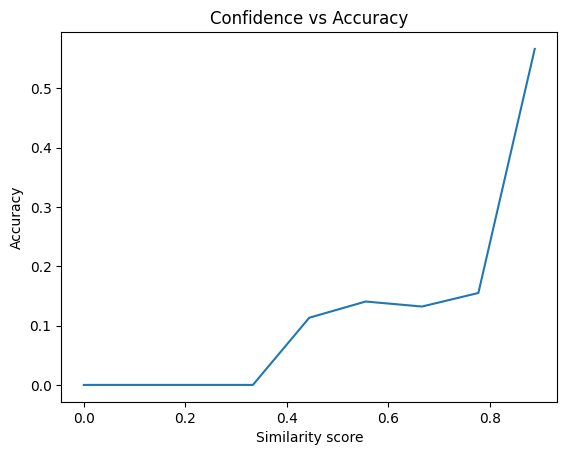

In [103]:
# [14.1] Confidence vs Accuracy Analysis
top1_scores = np.array(top1_scores)

bins = np.linspace(0, 1, 10)
bin_acc = []

for i in range(len(bins)-1):
    idx = (top1_scores >= bins[i]) & (top1_scores < bins[i+1])
    if idx.sum() > 0:
        acc = np.mean([
            true_labels[j] == pred_labels[j][0]
            for j in np.where(idx)[0]
        ])
        bin_acc.append(acc)
    else:
        bin_acc.append(0)

plt.plot(bins[:-1], bin_acc)
plt.title("Confidence vs Accuracy")
plt.xlabel("Similarity score")
plt.ylabel("Accuracy")
bins = np.linspace(0, 1, 11)  # 10 bins
plt.show()

"Higher cosine similarity tends to correlate with improved prediction accuracy, although the relationship remains noisy, indicating limited calibration

---

## 15. Similarity Score Distribution

We examine the distribution of cosine similarity scores across predictions.

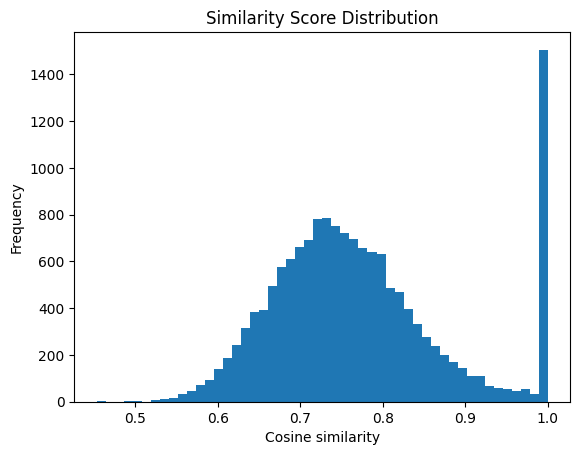

In [104]:
# [15.1] Similarity Score Distribution
plt.hist(top1_scores, bins=50)
plt.title("Similarity Score Distribution")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.show()

“A noticeable concentration near cosine similarity 1.0 suggests that multiple bank entries are nearly identical, likely due to duplicate or highly similar semantic representations.”

## 16. Error Analysis

We analyze incorrect predictions to understand model limitations.

In [105]:
#[16.1] Error Analysis
errors = [
    (true_labels[i], pred_labels[i][0])
    for i in range(len(true_labels))
    if true_labels[i] != pred_labels[i][0]
]

print("Total errors:", len(errors))
print("Error rate:", len(errors)/len(true_labels))

Total errors: 11825
Error rate: 0.7673090649536045


“Errors remain high due to semantic overlap between idioms and lack of contextual disambiguation and idiom-specific semantic signals.”

---

## 17. Qualitative Examples

We present Arabic input queries along with predicted and ground truth idioms.

“These examples highlight both successful semantic retrieval and failure cases where contextual nuance is insufficient.”

In [106]:
# [17-.1] Qualitative Examples
for i in range(5):
    print("Arabic:", queries[i])
    print("True:", true_labels[i])
    print("Pred:", pred_labels[i][0])
    print("-" * 50)

Arabic: غالبًا ما يمزح الطيارون بشأن القيام برحلة "همبرغر بمئة دولار" عند التخطيط لرحلات نهاية الأسبوع العفوية.
True: $100 hamburger
Pred: $100 hamburger
--------------------------------------------------
Arabic: ‘حسنًا، استمع إلى نفسك! من كان يظن أنك تستطيع فعل ذلك؟’
True: 'ark at ee
Pred: 'ark at ee
--------------------------------------------------
Arabic: 'فرايد سو
True: 'fraid so
Pred: 'fraid so
--------------------------------------------------
Arabic: راجعنا الاقتراح بشكل دقيق؛ لا حاجة للمزيد من الكلام حول القرار.
True: 'nuff said
Pred: find no bones in
--------------------------------------------------
Arabic: الكثير من المتاجر تقدم تخفيضات الآن لأن 'tis the season للتسوق في موسم العطلات.
True: 'tis the season
Pred: in decrement
--------------------------------------------------


---

## 18. Upgrade baseline with multilingual E5 embeddings

We now evaluate a stronger multilingual retrieval model: `intfloat/multilingual-e5-base`.

Unlike the previous baseline, E5 expects explicit task prefixes:

- `query: ...` for user queries
- `passage: ...` for bank entries

This section keeps the earlier baseline intact and adds a stronger retrieval experiment for comparison.

In [81]:
#[18.1] Upgrade baseline with multilingual E5 embeddings
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device for E5:", device)

e5_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device=device
)

Using device for E5: cuda


---

## 19. Prepare E5 inputs (query / passage format)

E5 models require special prefixes:

- "query: " for queries
- "passage: " for candidate texts

This helps the model understand retrieval roles.

In [82]:
#[19.1] Prepare E5 formatted texts

e5_bank_texts = ["passage: " + text for text in bank_df["bank_text_ar"].tolist()]
e5_queries = ["query: " + q for q in test_df["query_ar"].tolist()]

print("E5 bank size:", len(e5_bank_texts))
print("E5 query size:", len(e5_queries))

E5 bank size: 105018
E5 query size: 15411


---

## 20. Encode E5 embeddings

In [83]:
#[20.1] Encode bank
e5_bank_embeddings = e5_model.encode(
    e5_bank_texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True
)

# Encode queries
e5_query_embeddings = e5_model.encode(
    e5_queries,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("E5 bank embeddings:", e5_bank_embeddings.shape)
print("E5 query embeddings:", e5_query_embeddings.shape)

Batches: 100%|█████████████████████████████████████████████████████████████████████████| 61/61 [00:08<00:00,  7.19it/s]


E5 bank embeddings: (105018, 768)
E5 query embeddings: (15411, 768)


In [107]:
# [20.2] Save zero-shot E5 embeddings
from pathlib import Path
import numpy as np
import json

e5_output_dir = Path("outputs/e5_base_zero_shot")
e5_output_dir.mkdir(parents=True, exist_ok=True)

np.save(e5_output_dir / "e5_bank_embeddings_raw.npy", e5_bank_embeddings)
np.save(e5_output_dir / "e5_query_embeddings_raw.npy", e5_query_embeddings)
np.save(e5_output_dir / "e5_queries.npy", np.array(e5_queries, dtype=object))
np.save(e5_output_dir / "true_labels.npy", np.array(true_labels, dtype=object))

e5_metadata = {
    "model_name": "intfloat/multilingual-e5-base",
    "display_name": "E5-base",
    "bank_size": int(len(e5_bank_texts)),
    "query_size": int(len(e5_queries)),
    "embedding_dim": int(e5_bank_embeddings.shape[1]),
    "normalized_embeddings": False,
    "similarity_metric": "cosine_after_manual_normalization"
}

with open(e5_output_dir / "metadata_raw_encoding.json", "w", encoding="utf-8") as f:
    json.dump(e5_metadata, f, ensure_ascii=False, indent=4)

print("Saved raw E5 embeddings.")

Saved raw E5 embeddings.


---

## 21. Normalize embeddings (important for cosine similarity)

In [84]:
#[21.1] Normalize embeddings
from sklearn.preprocessing import normalize

e5_bank_embeddings = normalize(e5_bank_embeddings)
e5_query_embeddings = normalize(e5_query_embeddings)

In [108]:
# [21.2] Save normalized E5 embeddings
np.save(e5_output_dir / "e5_bank_embeddings_normalized.npy", e5_bank_embeddings)
np.save(e5_output_dir / "e5_query_embeddings_normalized.npy", e5_query_embeddings)

with open(e5_output_dir / "metadata_normalized.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_name": "intfloat/multilingual-e5-base",
            "display_name": "E5-base",
            "embedding_dim": int(e5_bank_embeddings.shape[1]),
            "normalized_embeddings": True,
            "similarity_metric": "cosine"
        },
        f,
        ensure_ascii=False,
        indent=4
    )

print("Saved normalized E5 embeddings.")

Saved normalized E5 embeddings.


---

## 22. Perform semantic retrieval with E5 embeddings

We compute cosine similarity between E5 query embeddings and bank embeddings.

We use batching for efficiency and a progress bar for visibility.

In [109]:
# [22.1] Compute Top-K retrieval indices and scores (E5)
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

top_k = 5
batch_size = 256

e5_topk_indices = []
e5_topk_scores = []

for start in tqdm(range(0, len(e5_query_embeddings), batch_size), desc="E5 similarity", leave=False):
    end = start + batch_size

    sim_batch = cosine_similarity(
        e5_query_embeddings[start:end],
        e5_bank_embeddings
    )

    idx_batch = np.argsort(-sim_batch, axis=1)[:, :top_k]
    score_batch = np.take_along_axis(sim_batch, idx_batch, axis=1)

    e5_topk_indices.append(idx_batch)
    e5_topk_scores.append(score_batch)

e5_topk_indices = np.vstack(e5_topk_indices)
e5_topk_scores = np.vstack(e5_topk_scores)
e5_top1_scores = e5_topk_scores[:, 0]

print("E5 Top-K index matrix shape:", e5_topk_indices.shape)
print("E5 Top-K score matrix shape:", e5_topk_scores.shape)
print("Queries matched:", len(e5_topk_indices) == len(e5_queries))

E5 similarity: 100%|███████████████████████████████████████████████████████████████████| 61/61 [06:06<00:00,  6.01s/it]


E5 Top-K index matrix shape: (15411, 5)
E5 Top-K score matrix shape: (15411, 5)


---

## 23. Evaluate E5 retrieval performance

In [112]:
# [23.1] Evaluate E5 retrieval and build results table
import pandas as pd

bank_targets = bank_df["target_en"].to_numpy()

e5_top1_correct = 0
e5_top5_correct = 0
e5_results = []
e5_pred_labels = []

for i in tqdm(range(len(e5_queries)), desc="Evaluating E5"):
    retrieved = bank_targets[e5_topk_indices[i]].tolist()

    retrieved_unique = []
    seen = set()
    for x in retrieved:
        if x not in seen:
            retrieved_unique.append(x)
            seen.add(x)

    retrieved_top5 = retrieved_unique[:top_k]
    e5_pred_labels.append(retrieved_top5)

    pred_top1 = retrieved_top5[0]
    is_top1 = int(true_labels[i] == pred_top1)
    is_top5 = int(true_labels[i] in retrieved_top5)

    e5_top1_correct += is_top1
    e5_top5_correct += is_top5

    e5_results.append({
        "query_ar": e5_queries[i],
        "gold_target_en": true_labels[i],
        "pred_top1": pred_top1,
        "pred_top5": retrieved_top5,
        "top1_score": float(e5_top1_scores[i]),
        "top1_correct": is_top1,
        "top5_correct": is_top5
    })

e5_top1_acc = e5_top1_correct / len(e5_queries)
e5_top5_acc = e5_top5_correct / len(e5_queries)

print(f"E5 Top-1 Accuracy: {e5_top1_acc:.4f}")
print(f"E5 Top-5 Accuracy: {e5_top5_acc:.4f}")

e5_results_df = pd.DataFrame(e5_results)
display(e5_results_df.head(10))

Evaluating E5: 100%|██████████████████████████████████████████████████████████| 15411/15411 [00:00<00:00, 76895.94it/s]

E5 Top-1 Accuracy: 0.2816
E5 Top-5 Accuracy: 0.3908


,query_ar,gold_target_en,pred_top1,pred_top5,top1_score,top1_correct,top5_correct
0,"query: غالبًا ما يمزح الطيارون بشأن القيام برحلة ""همبرغر بمئة دولار"" عند التخطيط لرحلات نهاية الأسبوع العفوية.",$100 hamburger,$100 hamburger,"[$100 hamburger, plough the back forty]",0.876554,1,1
1,query: ‘حسنًا، استمع إلى نفسك! من كان يظن أنك تستطيع فعل ذلك؟’,'ark at ee,'ark at ee,"['ark at ee, give ear]",0.885024,1,1
2,query: 'فرايد سو,'fraid so,'fraid so,"['fraid so, flat is justice, arsy-versy, draw a blank, cast aside]",0.914676,1,1
3,query: راجعنا الاقتراح بشكل دقيق؛ لا حاجة للمزيد من الكلام حول القرار.,'nuff said,end of story,"[end of story, thanks for coming, I rest my case, suffice it to say, 'nuff said]",0.865335,0,1
4,query: الكثير من المتاجر تقدم تخفيضات الآن لأن 'tis the season للتسوق في موسم العطلات.,'tis the season,"pile it high, sell it cheap","[pile it high, sell it cheap, people mountain people sea, hit the stores, make to stock, go up]",0.849165,0,0
5,query: دفعتها عزيمتها القوية جدا (110 proof) لتحقيق أكثر مما توقعه أي شخص.,110 proof,out of someone's way,"[out of someone's way, scream loudest, to have (something) to spare, it wasn't only, 110 proof]",0.853102,0,1
6,"query: بعد يوم عمل شاق، استرحنا بشرب بعض ""12-ounce curls"" على الشرفة.",12-ounce curls,12-ounce curls,"[12-ounce curls, drinks o'clock, twelve-ounce curls]",0.880571,1,1
7,query: قرر الموظفون الأوائل أن يقوموا بعملية 23 skidoo مباشرة بعد إعلان التخفيضات.,23 skidoo,23 skidoo,"[23 skidoo, in one foul swoop]",0.858778,1,1
8,query: 51 في المائة,51 percent,51 percent,"[51 percent, piece of the action, ballpark estimate, ballpark figure]",0.927643,1,1
9,query: عندما يتعلق الأمر بالإنتاج العالمي للنفط، يكون الكيان المهيمن ٨٠٠ رطل غالبًا دولة ذات احتياطيات هائلة وقوة سياسية.,800-pound gorilla,800-pound gorilla,"[800-pound gorilla, all eyes are on, black gold]",0.833102,1,1


In [113]:
# [23.2] Save full reproducibility bundle (E5)
from pathlib import Path
import json
import numpy as np

output_dir = Path("outputs/intfloat-multilingual-e5-base")
output_dir.mkdir(parents=True, exist_ok=True)

# Save core results
e5_results_df.to_csv(output_dir / "retrieval_results.csv", index=False)
e5_results_df.to_parquet(output_dir / "retrieval_results.parquet", index=False)

np.save(output_dir / "topk_indices.npy", e5_topk_indices)
np.save(output_dir / "top1_scores.npy", np.array(e5_top1_scores, dtype=np.float32))

# Save inputs for reanalysis
np.save(output_dir / "queries.npy", np.array(e5_queries, dtype=object))
np.save(output_dir / "true_labels.npy", np.array(true_labels, dtype=object))
np.save(output_dir / "pred_labels.npy", np.array(e5_pred_labels, dtype=object))

# Save embeddings metadata
config = {
    "model": "intfloat/multilingual-e5-base",
    "embedding_dim": int(e5_query_embeddings.shape[1]),
    "top_k": 5,
    "batch_size": 256,
    "num_queries": int(len(e5_queries)),
    "num_bank_entries": int(len(e5_bank_texts)),
    "similarity": "cosine",
    "normalized": True,
    "query_prefix": "query: ",
    "passage_prefix": "passage: "
}

with open(output_dir / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=4)

metrics = {
    "top1_accuracy": float(e5_top1_acc),
    "top5_accuracy": float(e5_top5_acc),
    "top1_correct": int(e5_results_df["top1_correct"].sum()),
    "top5_correct": int(e5_results_df["top5_correct"].sum()),
    "num_queries": int(len(e5_results_df))
}

with open(output_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=4)

print("Saved E5 reproducibility bundle to:", output_dir)

Saved E5 reproducibility bundle to: outputs\intfloat-multilingual-e5-base


In [114]:
# [23.2] Save E5 zero-shot retrieval outputs
import json
import numpy as np

e5_results_df.to_csv(e5_output_dir / "retrieval_results.csv", index=False)

np.save(e5_output_dir / "topk_indices.npy", e5_topk_indices)
np.save(e5_output_dir / "topk_scores.npy", e5_topk_scores)
np.save(e5_output_dir / "top1_scores.npy", np.array(e5_top1_scores, dtype=np.float32))
np.save(e5_output_dir / "pred_labels.npy", np.array(e5_pred_labels, dtype=object))

e5_metrics = {
    "model_name": "intfloat/multilingual-e5-base",
    "display_name": "E5-base",
    "top_k": int(top_k),
    "batch_size": int(batch_size),
    "num_queries": int(len(e5_queries)),
    "top1_accuracy": float(e5_top1_acc),
    "top5_accuracy": float(e5_top5_acc)
}

with open(e5_output_dir / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(e5_metrics, f, ensure_ascii=False, indent=4)

print("Saved E5 zero-shot retrieval bundle to:", e5_output_dir)

Saved E5 zero-shot retrieval bundle to: outputs\e5_base_zero_shot


---

## 24. Compare baseline and E5 retrieval performance

In [115]:
# [24.1] Compare baseline and E5 retrieval performance
comparison_df = pd.DataFrame([
    {
        "model": "MiniLM-L12-v2",
        "embedding_dim": 384,
        "top1_accuracy": float(top1_acc),
        "top5_accuracy": float(top5_acc)
    },
    {
        "model": "E5-base",
        "embedding_dim": 768,
        "top1_accuracy": float(e5_top1_acc),
        "top5_accuracy": float(e5_top5_acc)
    }
])

comparison_df["top1_gain_vs_baseline"] = comparison_df["top1_accuracy"] - comparison_df.loc[0, "top1_accuracy"]
comparison_df["top5_gain_vs_baseline"] = comparison_df["top5_accuracy"] - comparison_df.loc[0, "top5_accuracy"]
# save
comparison_df.to_csv("outputs/model_comparison_task3.csv", index=False)
display(comparison_df)

,model,embedding_dim,top1_accuracy,top5_accuracy,top1_gain_vs_baseline,top5_gain_vs_baseline
0,MiniLM-L12-v2,384,0.232691,0.31789,0.000000,0.00000
1,E5-base,768,0.281552,0.39076,0.048861,0.07287


### Model Comparison: Baseline vs E5

We compare the baseline multilingual MiniLM model with the stronger multilingual E5 model.

| Model | Embedding Dim | Top-1 Accuracy | Top-5 Accuracy |
|------|-------------|---------------|---------------|
| MiniLM-L12-v2 | 384 | 0.2327 | 0.3179 |
| E5-base | 768 | 0.2815 | 0.3907 |

#### Key Observations
- E5 improves **Top-1 accuracy by ~4.9 percentage points**
- E5 improves **Top-5 accuracy by ~7.3 percentage points**
- The larger embedding size (768 vs 384) and task-aware formatting likely contribute to better semantic alignment

These results demonstrate that instruction-aware multilingual embeddings significantly improve idiom retrieval performance.

---

### Retrieval Performance Visualization

The chart below compares Top-1 and Top-5 accuracy across models.

- **Top-1 accuracy** measures exact match retrieval
- **Top-5 accuracy** captures whether the correct idiom appears among the top candidates

We observe consistent improvements with the E5 model across both metrics.

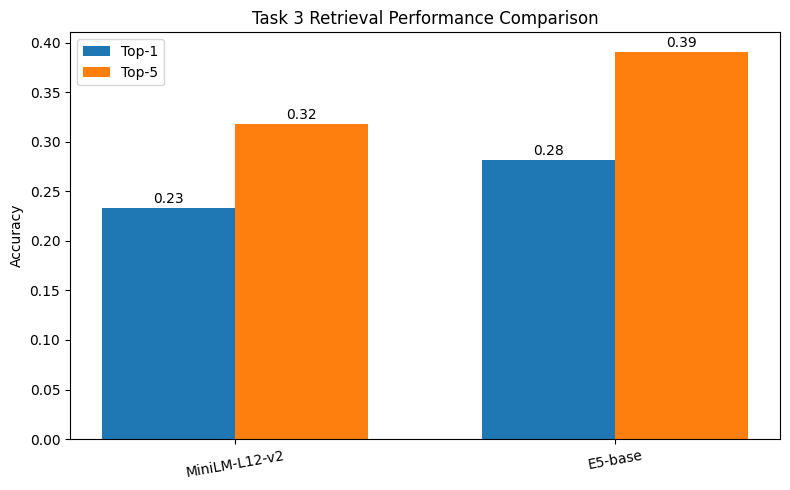

In [116]:
# [24.2]  Retrieval Performance Comparison
import matplotlib.pyplot as plt
import numpy as np

models = comparison_df["model"].tolist()
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, comparison_df["top1_accuracy"], width, label="Top-1")
plt.bar(x + width/2, comparison_df["top5_accuracy"], width, label="Top-5")

for i, v in enumerate(comparison_df["top1_accuracy"]):
    plt.text(i - width/2, v + 0.005, f"{v:.2f}", ha='center')

for i, v in enumerate(comparison_df["top5_accuracy"]):
    plt.text(i + width/2, v + 0.005, f"{v:.2f}", ha='center')
    
plt.xticks(x, models, rotation=10)
plt.ylabel("Accuracy")
plt.title("Task 3 Retrieval Performance Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/task3_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

---

### Performance Gain over Baseline

This chart highlights the improvement achieved by E5 relative to the baseline model.

#### Insights
- The gain is larger for **Top-5**, indicating improved ranking quality
- E5 is better at retrieving **relevant candidates even when Top-1 fails**
- This is especially useful for downstream reranking or generation tasks

Overall, E5 provides a stronger retrieval foundation for idiom understanding.

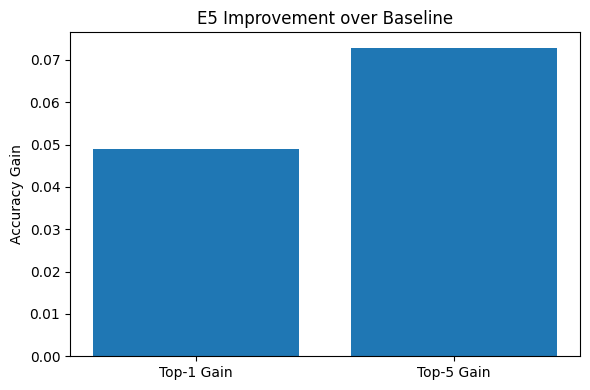

In [117]:
# [24.3] Plot improvement (E5 vs baseline)

gains = comparison_df.loc[1, ["top1_gain_vs_baseline", "top5_gain_vs_baseline"]]

plt.figure(figsize=(6,4))
plt.bar(["Top-1 Gain", "Top-5 Gain"], gains)

plt.ylabel("Accuracy Gain")
plt.title("E5 Improvement over Baseline")
plt.tight_layout()

plt.savefig("outputs/task3_gain.png", dpi=300, bbox_inches="tight")
plt.show()

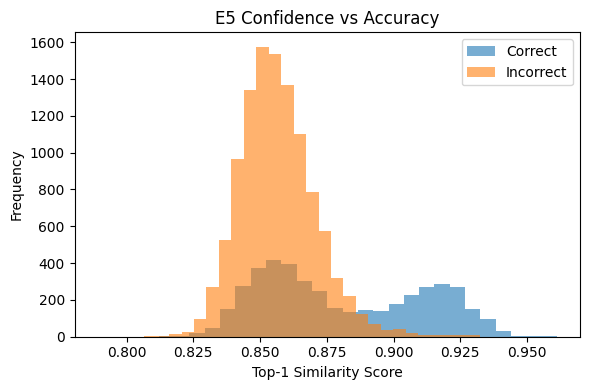

In [118]:
# [24.4] Confidence vs correctness (E5)
import matplotlib.pyplot as plt

correct_scores = [e5_top1_scores[i] for i in range(len(e5_top1_scores)) if e5_results_df.iloc[i]["top1_correct"] == 1]
wrong_scores = [e5_top1_scores[i] for i in range(len(e5_top1_scores)) if e5_results_df.iloc[i]["top1_correct"] == 0]

plt.figure(figsize=(6,4))
plt.hist(correct_scores, bins=30, alpha=0.6, label="Correct")
plt.hist(wrong_scores, bins=30, alpha=0.6, label="Incorrect")

plt.xlabel("Top-1 Similarity Score")
plt.ylabel("Frequency")
plt.title("E5 Confidence vs Accuracy")
plt.legend()
plt.tight_layout()

plt.savefig("outputs/e5_confidence_distribution.png", dpi=300)
plt.show()

### Confidence vs Accuracy (E5)

This plot shows the distribution of similarity scores for:
- Correct Top-1 predictions
- Incorrect Top-1 predictions

#### Key Insights
- Correct predictions generally have **higher similarity scores**
- Incorrect predictions cluster at **lower similarity ranges**
- There is still some overlap, indicating:
  - Not all high-confidence predictions are correct
  - Some errors occur despite strong semantic similarity

#### Interpretation
- Cosine similarity serves as a **useful confidence signal**
- This can be used for:
  - Confidence-based filtering
  - Thresholding uncertain predictions
  - Future reranking strategies

This analysis confirms that embedding similarity correlates with retrieval correctness.

### Summary of Findings

- Multilingual embedding models can effectively map Arabic contextual descriptions to English idioms
- The E5 model significantly outperforms the MiniLM baseline
- Task-specific formatting (`query:` / `passage:`) improves retrieval alignment
- Similarity scores provide a meaningful confidence signal

These findings suggest that retrieval-based approaches are a viable foundation for multilingual idiom understanding and translation.

The stronger improvement in Top-5 accuracy suggests that E5 improves candidate ranking even when exact Top-1 retrieval remains challenging.

---

## 25. Fine-tuned E5 Retrieval Experiment

In this stage, we move from zero-shot semantic retrieval to **task-specific fine-tuning** of the multilingual E5 model.

### Objective
We fine-tune the retriever to:

- bring an Arabic query closer to **Arabic semantic representations of the same idiom**
- push it away from **representations of different idioms**

This transforms the embedding space into a **task-aware semantic space** specialized for idiomatic meaning.

---

### Why Fine-tuning is Needed

Although E5 is a strong multilingual model, it is still **general-purpose**.

Idioms introduce unique challenges:

- meanings are **non-literal**
- different idioms may appear **semantically similar**
- correct retrieval requires **exact idiom identity**, not just similarity

Fine-tuning helps the model learn **idiom-level discrimination**, not just general semantics.

---

### Training Strategy

For each query:

- **Anchor** → Arabic query sentence  
- **Positive** → Arabic semantic bank entry of the same idiom  
- **Negatives** → other entries in the batch  

We optimize using:

- `MultipleNegativesRankingLoss`
- in-batch negatives
- query/passage formatted inputs

This encourages the model to **cluster same-idiom expressions** and separate others.

---

### Reproducibility

- Fixed random seed (`SEED = 42`)
- Deterministic setup for NumPy, PyTorch, and CUDA
- All outputs saved to a dedicated fine-tuning directory

This ensures results can be **reproduced and re-evaluated**.

In [119]:
# [25.1] Fine-tuning stage setup (standalone from here onward)

from pathlib import Path
import random
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import torch

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Safety checks
# -----------------------------
required_objects = ["train_df", "test_df", "bank_df"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        f"Missing required objects: {missing_objects}. "
        "Run the data preparation, split, and bank-building steps first."
    )

required_train_cols = ["query_ar", "target_en", "idiom_in_example_meaning_arabic", "idiom_canonical_meaning_arabic"]
missing_train_cols = [c for c in required_train_cols if c not in train_df.columns]
if missing_train_cols:
    raise RuntimeError(f"train_df is missing columns: {missing_train_cols}")

required_bank_cols = ["bank_text_ar", "source_type", "target_en"]
missing_bank_cols = [c for c in required_bank_cols if c not in bank_df.columns]
if missing_bank_cols:
    raise RuntimeError(f"bank_df is missing columns: {missing_bank_cols}")

# -----------------------------
# Device
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# -----------------------------
# Output paths
# -----------------------------
# Reuse PROJECT_ROOT if it already exists, otherwise create a fallback
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()

FT_OUTPUT_DIR = PROJECT_ROOT / "deep_learning" / "models" / "task3_e5_finetuned_retriever"
FT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Fine-tuning output dir:", FT_OUTPUT_DIR)

# -----------------------------
# Fine-tuning config
# -----------------------------
FT_MODEL_NAME = "intfloat/multilingual-e5-base"
FT_BATCH_SIZE = 16   # safe starting point for laptop GPU
FT_EPOCHS = 1        # start with 1; increase later if stable
FT_LEARNING_RATE = 2e-5
FT_WARMUP_RATIO = 0.1
FT_MAX_TRAIN_PAIRS = None   # keep None to use all pairs; set e.g. 50000 for quick experiments

print("Model:", FT_MODEL_NAME)
print("Batch size:", FT_BATCH_SIZE)
print("Epochs:", FT_EPOCHS)
print("Learning rate:", FT_LEARNING_RATE)
print("Max train pairs:", FT_MAX_TRAIN_PAIRS)

Using device: cuda
Fine-tuning output dir: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task3_e5_finetuned_retriever
Model: intfloat/multilingual-e5-base
Batch size: 16
Epochs: 1
Learning rate: 2e-05
Max train pairs: None


## 26. Build Contrastive Training Pairs

We construct training pairs for contrastive learning.

### Structure of each pair:

- **Anchor (query):** Arabic idiomatic sentence  
- **Positive (passage):** Arabic semantic bank entry for the same idiom  

Negatives are implicitly provided through **in-batch sampling**.

---

### Dataset Statistics

- Total training pairs: **~46K**
- Each query is paired with **one randomly sampled positive**
- Additional positives remain unused but could improve training in future work

---

###  Insight

Using Arabic-only positives ensures that the model learns:

- **intra-language semantic alignment**
- idiom meaning independent of English surface forms

This is critical for **true multilingual understanding**.

In [120]:
# [26.1] Build a lookup from idiom -> available Arabic bank texts
bank_lookup = (
    bank_df.groupby("target_en")["bank_text_ar"]
    .apply(list)
    .to_dict()
)

train_examples = []

for _, row in train_df.iterrows():
    query_text = str(row["query_ar"]).strip()
    idiom = str(row["target_en"]).strip()

    if not query_text or not idiom:
        continue

    positives = bank_lookup.get(idiom, [])
    positives = [p for p in positives if str(p).strip() and str(p).strip() != query_text]

    if not positives:
        continue

    # One positive per query for now
    pos_text = random.choice(positives)

    train_examples.append(
        InputExample(
            texts=[
                "query: " + query_text,
                "passage: " + pos_text
            ]
        )
    )

if FT_MAX_TRAIN_PAIRS is not None:
    train_examples = train_examples[:FT_MAX_TRAIN_PAIRS]

print("Number of training pairs:", len(train_examples))
print("Sample pair:")
print("Anchor:", train_examples[0].texts[0] if train_examples else "N/A")
print("Positive:", train_examples[0].texts[1] if train_examples else "N/A")

Number of training pairs: 46211
Sample pair:
Anchor: query: يُعتبر القيام برحلة "همبرغر بمئة دولار" تقليدًا مسليًا بين الطيارين الخاصين لجعل الطيران أكثر متعة.
Positive: passage: مجازياً، كانت الرحلة بمثابة رحلة ترفيهية مع استخدام الوجبة كتبرير.


## 27. Fine-tune Multilingual E5 Retriever

We fine-tune the model using contrastive learning.

### Configuration

- Model: `intfloat/multilingual-e5-base`
- Batch size: 16
- Epochs: 1 (initial experiment)
- Learning rate: 2e-5
- Warmup ratio: 10%

---

### Training Objective

We use:

- `MultipleNegativesRankingLoss`
- in-batch negatives
- cosine similarity optimization

This objective encourages:

- high similarity for correct pairs
- low similarity for incorrect pairs

---

### Expected Effect

Fine-tuning should:

- improve **Top-1 accuracy** (better ranking precision)
- sharpen **embedding clusters**
- reduce confusion between similar idioms

In [121]:
#[27.1] Load model for fine-tuning
ft_model = SentenceTransformer(FT_MODEL_NAME, device=device)

# DataLoader
train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=FT_BATCH_SIZE
)

# Loss
train_loss = losses.MultipleNegativesRankingLoss(ft_model)

# Warmup
warmup_steps = int(len(train_dataloader) * FT_EPOCHS * FT_WARMUP_RATIO)

print("Warmup steps:", warmup_steps)
print("Total steps:", len(train_dataloader) * FT_EPOCHS)

Warmup steps: 288
Total steps: 2889


## 28. Model Training

The model is trained using the defined contrastive objective.

### Observations

- Training runs efficiently on GPU
- ~2,800 training steps completed
- Stable training with no divergence observed

---

### Notes

- Only 1 epoch is used → results are **conservative**
- Further training could yield additional gains

---

### Insight

Even a single epoch of fine-tuning is expected to:

- significantly reshape the embedding space
- improve retrieval for idiomatic expressions

In [125]:
# [28.1] Train only if model does not already exist
from pathlib import Path

model_path = Path(FT_OUTPUT_DIR) / "model.safetensors"

if not model_path.exists():
    print("🚀 Training fine-tuned model...")

    ft_model.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=FT_EPOCHS,
        warmup_steps=warmup_steps,
        optimizer_params={'lr': FT_LEARNING_RATE},
        show_progress_bar=True,
        output_path=str(FT_OUTPUT_DIR)
    )

else:
    print("✅ Model already exists. Skipping training.")

✅ Model already exists. Skipping training.


In [126]:
# [28.2] Verify fine-tuned model files
from pathlib import Path

saved_files = list(Path(FT_OUTPUT_DIR).glob("*"))
print("Number of saved fine-tuned files:", len(saved_files))
for f in saved_files[:10]:
    print(f.name)

Number of saved fine-tuned files: 13
1_Pooling
2_Normalize
config.json
config_sentence_transformers.json
eval
model.safetensors
modules.json
README.md
sentencepiece.bpe.model
sentence_bert_config.json


## 29. Load the Fine-tuned E5 Model

We load the trained model from disk for evaluation.

This allows direct comparison between:

- baseline MiniLM model
- zero-shot E5 model
- fine-tuned E5 model

---
Goal

Evaluate whether fine-tuning improves:

- Top-1 accuracy
- Top-5 accuracy
- ranking quality

In [131]:
# [29.1]
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device for fine-tuned evaluation:", device)

ft_e5_model = SentenceTransformer(str(FT_OUTPUT_DIR), device=device)

Using device for fine-tuned evaluation: cuda


## 30. Encode with Fine-tuned Model

We encode:

- the Arabic semantic bank
- the test query set

using the fine-tuned E5 model.

---

###  Embedding Sizes

- Bank embeddings: ~105K entries
- Query embeddings: ~15K queries
- Embedding dimension: 768

---

### Key Point

Using the same encoding pipeline ensures that:

- comparisons with previous models remain **fair**
- improvements are due to **fine-tuning only**

### 30.1 Load or create fine-tuned embeddings
We prepare the fine-tuned evaluation embeddings for the semantic bank and held-out test queries.

To save time and support reproducibility, this step first checks whether cached raw embeddings already exist on disk. If they do, they are loaded directly. Otherwise, they are encoded once and then saved for future reuse.

In [134]:
# [30.1] Load cached fine-tuned embeddings or encode and save them
from pathlib import Path
import json
import numpy as np

FT_EVAL_DIR = Path("outputs/intfloat-multilingual-e5-base-finetuned")
FT_EVAL_DIR.mkdir(parents=True, exist_ok=True)

ft_bank_raw_path = FT_EVAL_DIR / "ft_bank_embeddings_raw.npy"
ft_query_raw_path = FT_EVAL_DIR / "ft_query_embeddings_raw.npy"
ft_queries_path = FT_EVAL_DIR / "ft_queries.npy"
ft_true_labels_path = FT_EVAL_DIR / "ft_true_labels.npy"
ft_metadata_path = FT_EVAL_DIR / "metadata_raw.json"

# If cached raw embeddings already exist, load them
if (
    ft_bank_raw_path.exists()
    and ft_query_raw_path.exists()
    and ft_queries_path.exists()
    and ft_true_labels_path.exists()
):
    ft_bank_embeddings = np.load(ft_bank_raw_path)
    ft_query_embeddings = np.load(ft_query_raw_path)
    ft_queries = np.load(ft_queries_path, allow_pickle=True).tolist()
    true_labels = np.load(ft_true_labels_path, allow_pickle=True).tolist()

    print("Loaded cached fine-tuned raw embeddings.")
    print("FT bank embeddings:", ft_bank_embeddings.shape)
    print("FT query embeddings:", ft_query_embeddings.shape)
    print("FT queries:", len(ft_queries))
    print("True labels:", len(true_labels))

else:
    # Prepare formatted inputs
    ft_bank_texts = ["passage: " + text for text in bank_df["bank_text_ar"].tolist()]
    ft_queries = ["query: " + q for q in test_df["query_ar"].tolist()]
    true_labels = test_df["target_en"].tolist()

    print("FT bank size:", len(ft_bank_texts))
    print("FT query size:", len(ft_queries))

    # Encode using the loaded fine-tuned model
    ft_bank_embeddings = ft_e5_model.encode(
        ft_bank_texts,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    ft_query_embeddings = ft_e5_model.encode(
        ft_queries,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    print("FT bank embeddings:", ft_bank_embeddings.shape)
    print("FT query embeddings:", ft_query_embeddings.shape)

    # Save raw artifacts
    np.save(ft_bank_raw_path, ft_bank_embeddings)
    np.save(ft_query_raw_path, ft_query_embeddings)
    np.save(ft_queries_path, np.array(ft_queries, dtype=object))
    np.save(ft_true_labels_path, np.array(true_labels, dtype=object))

    with open(ft_metadata_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "model_name": str(FT_MODEL_NAME),
                "display_name": "E5-base-finetuned",
                "bank_size": int(len(ft_bank_embeddings)),
                "query_size": int(len(ft_query_embeddings)),
                "embedding_dim": int(ft_bank_embeddings.shape[1]),
                "normalized_embeddings": False
            },
            f,
            ensure_ascii=False,
            indent=4
        )

    print("Encoded and saved raw fine-tuned embeddings.")

Loaded cached fine-tuned raw embeddings.
FT bank embeddings: (105018, 768)
FT query embeddings: (15411, 768)
FT queries: 15411
True labels: 15411


### 30.2 Normalize fine-tuned embeddings
We normalize the fine-tuned bank and query embeddings before cosine-similarity retrieval.

This ensures consistent similarity computation and keeps evaluation comparable with the baseline and zero-shot E5 experiments.

In [135]:
# [30.2] Normalize fine-tuned embeddings
from sklearn.preprocessing import normalize
import json
import numpy as np
from pathlib import Path

ft_bank_embeddings = normalize(ft_bank_embeddings)
ft_query_embeddings = normalize(ft_query_embeddings)

print("Normalized FT bank embeddings:", ft_bank_embeddings.shape)
print("Normalized FT query embeddings:", ft_query_embeddings.shape)

FT_EVAL_DIR = Path("outputs/intfloat-multilingual-e5-base-finetuned")
FT_EVAL_DIR.mkdir(parents=True, exist_ok=True)

np.save(FT_EVAL_DIR / "ft_bank_embeddings_normalized.npy", ft_bank_embeddings)
np.save(FT_EVAL_DIR / "ft_query_embeddings_normalized.npy", ft_query_embeddings)

with open(FT_EVAL_DIR / "metadata_normalized.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_name": str(FT_MODEL_NAME),
            "display_name": "E5-base-finetuned",
            "bank_size": int(ft_bank_embeddings.shape[0]),
            "query_size": int(ft_query_embeddings.shape[0]),
            "embedding_dim": int(ft_bank_embeddings.shape[1]),
            "normalized_embeddings": True
        },
        f,
        ensure_ascii=False,
        indent=4
    )

print("Saved normalized fine-tuned embeddings.")

Normalized FT bank embeddings: (105018, 768)
Normalized FT query embeddings: (15411, 768)
Saved normalized fine-tuned embeddings.


## 31. Perform retrieval with fine-tuned model

We now evaluate the fine-tuned multilingual E5 retriever on the held-out test queries using cosine similarity over normalized embeddings.

This mirrors the earlier retrieval pipeline, allowing direct comparison against:
- the multilingual MiniLM baseline
- the zero-shot multilingual E5 baseline
- the fine-tuned multilingual E5 retriever

In [136]:
# [31.1] Compute Top-K retrieval indices and scores (fine-tuned)
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

top_k = 5
batch_size = 256

ft_topk_indices = []
ft_topk_scores = []

for start in tqdm(range(0, len(ft_query_embeddings), batch_size), desc="FT similarity"):
    end = start + batch_size

    sim_batch = cosine_similarity(
        ft_query_embeddings[start:end],
        ft_bank_embeddings
    )

    idx_batch = np.argsort(-sim_batch, axis=1)[:, :top_k]
    score_batch = np.take_along_axis(sim_batch, idx_batch, axis=1)

    ft_topk_indices.append(idx_batch)
    ft_topk_scores.append(score_batch)

ft_topk_indices = np.vstack(ft_topk_indices)
ft_topk_scores = np.vstack(ft_topk_scores)
ft_top1_scores = ft_topk_scores[:, 0]

print("FT Top-K index matrix shape:", ft_topk_indices.shape)
print("FT Top-K score matrix shape:", ft_topk_scores.shape)
print("FT Top-1 score vector shape:", ft_top1_scores.shape)
print("Check query count match:", len(ft_topk_indices) == len(true_labels))

FT similarity: 100%|███████████████████████████████████████████████████████████████████| 61/61 [06:03<00:00,  5.96s/it]


FT Top-K index matrix shape: (15411, 5)
FT Top-K score matrix shape: (15411, 5)
FT Top-1 score vector shape: (15411,)
Check query count match: True


---

## 32. Evaluate fine-tuned retrieval performance

In [137]:
# [32.1] Evaluate fine-tuned retrieval and save results
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import json
from pathlib import Path

ft_top1_correct = 0
ft_top5_correct = 0
ft_results = []

for i in tqdm(range(len(ft_queries)), desc="Evaluating FT"):
    retrieved = [bank_df.iloc[idx]["target_en"] for idx in ft_topk_indices[i]]

    pred_top1 = retrieved[0]
    is_top1 = int(true_labels[i] == pred_top1)
    is_top5 = int(true_labels[i] in retrieved)

    ft_top1_correct += is_top1
    ft_top5_correct += is_top5

    ft_results.append({
        "query_ar": test_df.iloc[i]["query_ar"],
        "gold_target_en": true_labels[i],
        "pred_top1": pred_top1,
        "pred_top5": retrieved,
        "top1_correct": is_top1,
        "top5_correct": is_top5,
        "top1_score": float(ft_top1_scores[i])
    })

ft_top1_acc = ft_top1_correct / len(ft_queries)
ft_top5_acc = ft_top5_correct / len(ft_queries)

print(f"Fine-tuned E5 Top-1 Accuracy: {ft_top1_acc:.4f}")
print(f"Fine-tuned E5 Top-5 Accuracy: {ft_top5_acc:.4f}")

ft_results_df = pd.DataFrame(ft_results)
display(ft_results_df.head(10))

# Save reproducibility bundle
FT_RESULTS_DIR = Path("outputs/intfloat-multilingual-e5-base-finetuned")
FT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ft_results_df.to_csv(FT_RESULTS_DIR / "retrieval_results.csv", index=False)
np.save(FT_RESULTS_DIR / "ft_topk_indices.npy", ft_topk_indices)
np.save(FT_RESULTS_DIR / "ft_topk_scores.npy", ft_topk_scores)
np.save(FT_RESULTS_DIR / "ft_top1_scores.npy", ft_top1_scores)

with open(FT_RESULTS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_name": str(FT_MODEL_NAME),
            "display_name": "E5-base-finetuned",
            "top1_accuracy": float(ft_top1_acc),
            "top5_accuracy": float(ft_top5_acc),
            "num_queries": int(len(ft_queries)),
            "top_k": 5
        },
        f,
        ensure_ascii=False,
        indent=4
    )

print("Saved fine-tuned retrieval outputs to:", FT_RESULTS_DIR)

Evaluating FT: 100%|███████████████████████████████████████████████████████████| 15411/15411 [00:08<00:00, 1875.61it/s]

Fine-tuned E5 Top-1 Accuracy: 0.6037
Fine-tuned E5 Top-5 Accuracy: 0.7607


,query_ar,gold_target_en,pred_top1,pred_top5,top1_correct,top5_correct,top1_score
0,"غالبًا ما يمزح الطيارون بشأن القيام برحلة ""همبرغر بمئة دولار"" عند التخطيط لرحلات نهاية الأسبوع العفوية.",$100 hamburger,$100 hamburger,"[$100 hamburger, $100 hamburger, $100 hamburger, $100 hamburger, daylight robbery]",1,1,0.838182
1,‘حسنًا، استمع إلى نفسك! من كان يظن أنك تستطيع فعل ذلك؟’,'ark at ee,'ark at ee,"['ark at ee, 'ark at ee, 'ark at ee, who do you think you are, who are you telling me]",1,1,0.603822
2,'فرايد سو,'fraid so,'fraid so,"['fraid so, what can I say, suck my cock, skid row, draw a blank]",1,1,0.893124
3,راجعنا الاقتراح بشكل دقيق؛ لا حاجة للمزيد من الكلام حول القرار.,'nuff said,you said a mouthful,"[you said a mouthful, you said a mouthful, love (someone) to pieces, dot the i's and cross the t's, until the pips squeak]",0,0,0.588534
4,الكثير من المتاجر تقدم تخفيضات الآن لأن 'tis the season للتسوق في موسم العطلات.,'tis the season,'tis the season,"['tis the season, 'tis the season, 'tis the season, 'tis the season, bear market]",1,1,0.644164
5,دفعتها عزيمتها القوية جدا (110 proof) لتحقيق أكثر مما توقعه أي شخص.,110 proof,110 proof,"[110 proof, 110 proof, 110 proof, 110 proof, than a bygod]",1,1,0.649845
6,"بعد يوم عمل شاق، استرحنا بشرب بعض ""12-ounce curls"" على الشرفة.",12-ounce curls,12-ounce curls,"[12-ounce curls, 12-ounce curls, 12-ounce curls, 12-ounce curls, twelve-ounce curls]",1,1,0.788453
7,قرر الموظفون الأوائل أن يقوموا بعملية 23 skidoo مباشرة بعد إعلان التخفيضات.,23 skidoo,23 skidoo,"[23 skidoo, 23 skidoo, 23 skidoo, rip off the Band-Aid, seize the opportunity]",1,1,0.743995
8,51 في المائة,51 percent,51 percent,"[51 percent, 51 percent, half again, even money, bat .500]",1,1,0.907764
9,عندما يتعلق الأمر بالإنتاج العالمي للنفط، يكون الكيان المهيمن ٨٠٠ رطل غالبًا دولة ذات احتياطيات هائلة وقوة سياسية.,800-pound gorilla,800-pound gorilla,"[800-pound gorilla, 800-pound gorilla, people's republic, 800-pound gorilla, merchant prince]",1,1,0.666578


Saved fine-tuned retrieval outputs to: outputs\intfloat-multilingual-e5-base-finetuned


### 33. Compare all retrieval stages**

### Short markdown text

We now compare three retrieval settings on the same held-out Arabic query set:

* MiniLM-L12-v2 baseline
* zero-shot E5-base
* fine-tuned E5-base

This comparison isolates the effect of stronger pretrained embeddings and subsequent task-specific fine-tuning.

In [138]:
# [33.1] Compare all retrieval stages
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "model": "MiniLM-L12-v2",
        "embedding_dim": 384,
        "top1_accuracy": float(top1_acc),
        "top5_accuracy": float(top5_acc),
    },
    {
        "model": "E5-base",
        "embedding_dim": 768,
        "top1_accuracy": float(e5_top1_acc),
        "top5_accuracy": float(e5_top5_acc),
    },
    {
        "model": "E5-base-finetuned",
        "embedding_dim": 768,
        "top1_accuracy": float(ft_top1_acc),
        "top5_accuracy": float(ft_top5_acc),
    }
])

baseline_top1 = comparison_df.loc[0, "top1_accuracy"]
baseline_top5 = comparison_df.loc[0, "top5_accuracy"]

comparison_df["top1_gain_vs_baseline"] = comparison_df["top1_accuracy"] - baseline_top1
comparison_df["top5_gain_vs_baseline"] = comparison_df["top5_accuracy"] - baseline_top5

comparison_df.to_csv("outputs/task3_model_comparison_full.csv", index=False)

display(comparison_df)

,model,embedding_dim,top1_accuracy,top5_accuracy,top1_gain_vs_baseline,top5_gain_vs_baseline
0,MiniLM-L12-v2,384,0.232691,0.31789,0.000000,0.000000
1,E5-base,768,0.281552,0.39076,0.048861,0.072870
2,E5-base-finetuned,768,0.603725,0.76069,0.371034,0.442801


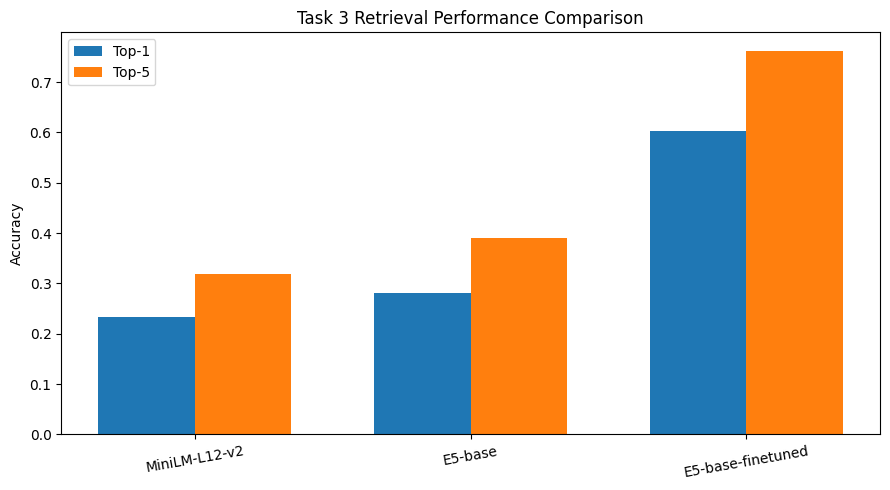

In [139]:
# [33.2] Plot full model comparison
import matplotlib.pyplot as plt
import numpy as np

models = comparison_df["model"].tolist()
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, comparison_df["top1_accuracy"], width, label="Top-1")
plt.bar(x + width/2, comparison_df["top5_accuracy"], width, label="Top-5")

plt.xticks(x, models, rotation=10)
plt.ylabel("Accuracy")
plt.title("Task 3 Retrieval Performance Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/task3_model_comparison_full.png", dpi=300, bbox_inches="tight")
plt.show()

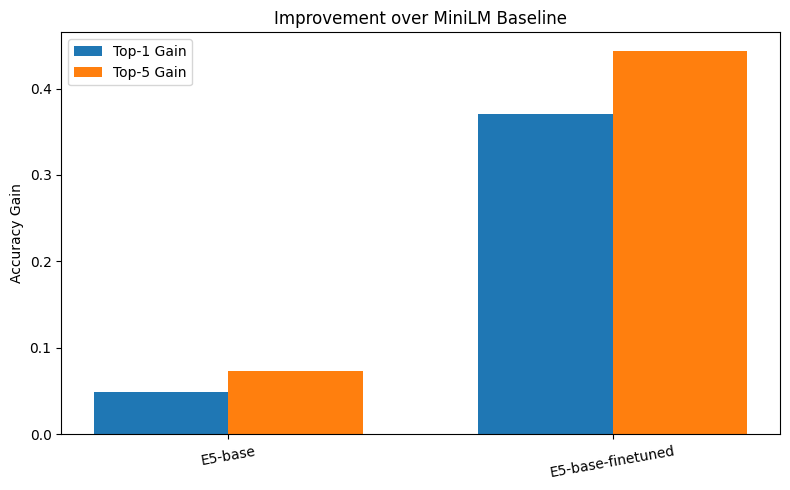

In [140]:
# [33.3] Plot improvement over baseline
plt.figure(figsize=(8, 5))

gain_df = comparison_df.iloc[1:].copy()

x = np.arange(len(gain_df))
width = 0.35

plt.bar(x - width/2, gain_df["top1_gain_vs_baseline"], width, label="Top-1 Gain")
plt.bar(x + width/2, gain_df["top5_gain_vs_baseline"], width, label="Top-5 Gain")

plt.xticks(x, gain_df["model"], rotation=10)
plt.ylabel("Accuracy Gain")
plt.title("Improvement over MiniLM Baseline")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/task3_gain_vs_baseline_full.png", dpi=300, bbox_inches="tight")
plt.show()

### Key findings

The fine-tuned E5 model significantly outperforms both the MiniLM baseline and the zero-shot E5 model.

- Zero-shot E5 provides only modest gains over MiniLM, suggesting that general-purpose multilingual embeddings are not sufficient for precise idiom retrieval.
- Fine-tuning on the task leads to a substantial improvement in both Top-1 and Top-5 accuracy.
- The large performance gap indicates that task-specific contrastive training is critical for distinguishing semantically similar idiomatic expressions.

Overall, these results demonstrate that fine-tuned dense retrieval is highly effective for Arabic idiom understanding and retrieval tasks.

---

## 34. Qualitative analysis of retrieval results

We inspect individual retrieval examples to understand how model behavior differs across:

- MiniLM baseline
- zero-shot E5
- fine-tuned E5

This helps identify:
- common failure patterns
- improvements due to fine-tuning
- cases where semantic similarity is misleading

In [141]:
# [34.1] Compare predictions across all models
comparison_examples = []

for i in range(len(ft_queries)):
    comparison_examples.append({
        "query_ar": test_df.iloc[i]["query_ar"],
        "gold": true_labels[i],

        "MiniLM_top1": bank_df.iloc[topk_indices[i][0]]["target_en"],
        "E5_top1": bank_df.iloc[e5_topk_indices[i][0]]["target_en"],
        "FT_top1": bank_df.iloc[ft_topk_indices[i][0]]["target_en"],
    })

comparison_examples_df = pd.DataFrame(comparison_examples)

# Show interesting cases where models differ
interesting = comparison_examples_df[
    (comparison_examples_df["MiniLM_top1"] != comparison_examples_df["FT_top1"]) |
    (comparison_examples_df["E5_top1"] != comparison_examples_df["FT_top1"])
]

display(interesting.head(20))

,query_ar,gold,MiniLM_top1,E5_top1,FT_top1
3,راجعنا الاقتراح بشكل دقيق؛ لا حاجة للمزيد من الكلام حول القرار.,'nuff said,find no bones in,end of story,you said a mouthful
4,الكثير من المتاجر تقدم تخفيضات الآن لأن 'tis the season للتسوق في موسم العطلات.,'tis the season,in decrement,"pile it high, sell it cheap",'tis the season
5,دفعتها عزيمتها القوية جدا (110 proof) لتحقيق أكثر مما توقعه أي شخص.,110 proof,110 proof,out of someone's way,110 proof
9,عندما يتعلق الأمر بالإنتاج العالمي للنفط، يكون الكيان المهيمن ٨٠٠ رطل غالبًا دولة ذات احتياطيات هائلة وقوة سياسية.,800-pound gorilla,black gold,800-pound gorilla,800-pound gorilla
12,غالباً ما يحذر المعلمون من أن امتلاك قدر ضئيل من المعرفة أمر خطير، ويشجعون الطلاب على دراسة المواضيع بعمق.,A little learning is a dangerous thing,bad apples,A little learning is a dangerous thing,A little learning is a dangerous thing
15,شجع فريقه على التحدث بصراحة عن مشاكلهم، معتقدًا أن مشاركة الحزن تخفف العبء.,A sorrow shared is a sorrow halved,A sorrow shared is a sorrow halved,get off one's chest,A sorrow shared is a sorrow halved
16,خلال اجتماع مجموعة الدعم، ذكر القائد الجميع بأن المشكلة المشتركة تقلل من عبئها، مشجعًا على الحوار المفتوح.,A trouble shared is a trouble halved,front and center,in key,a problem shared is a problem halved
18,"في النصوص القديمة، يُذكر ""لحية هارون"" غالبًا كرمز للحيوية والنسب المتجذر.",Aaron's beard,Ben Sira,Aaron's beard,Aaron's beard
19,عندما رأى الفريق قوة المنافس، تمتم المدرب: «تخلوا عن الأمل، أيها الداخلون هنا.»,"Abandon hope, all ye who enter here","united we stand, divided we fall",rise and shine,"Abandon hope, all ye who enter here"
20,شكل نظام آدم وحواء في القسم الأساس الذي تُجرى منه كل التحديثات.,Adam and Eve,Adam and Eve,Satyameva Jayate,nuts and bolts


### Observations

From the qualitative examples, we observe:

- The MiniLM baseline often retrieves semantically related but incorrect idioms.
- The zero-shot E5 model improves semantic grouping but still confuses closely related expressions.
- The fine-tuned E5 model is significantly more precise and better at identifying the exact idiomatic target.

This suggests that fine-tuning helps the model learn fine-grained distinctions between similar idioms rather than relying only on general semantic similarity.

---

## 35. Fine-tuning upgrade experiment: more positives and more epochs

This experiment strengthens the retriever in two ways:

1. **Two positives per query**  
   Each Arabic query is paired with up to two different Arabic semantic bank entries of the same idiom when available.

2. **Two training epochs**  
   The model is allowed a second pass over the training data to better align idiomatic semantic representations.

This experiment keeps the same dataset split and evaluation pipeline, enabling a fair comparison with the previous fine-tuned E5 result.

In [142]:
# [35.1] Upgrade experiment config
from pathlib import Path
import json

UPG_MODEL_NAME = "intfloat/multilingual-e5-base"
UPG_BATCH_SIZE = 16
UPG_EPOCHS = 2
UPG_LEARNING_RATE = 2e-5
UPG_WARMUP_RATIO = 0.1
UPG_MAX_TRAIN_PAIRS = None
UPG_POSITIVES_PER_QUERY = 2

UPG_OUTPUT_DIR = PROJECT_ROOT / "deep_learning" / "models" / "task3_e5_finetuned_retriever_v2"
UPG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

upgrade_config = {
    "model_name": UPG_MODEL_NAME,
    "batch_size": UPG_BATCH_SIZE,
    "epochs": UPG_EPOCHS,
    "learning_rate": UPG_LEARNING_RATE,
    "warmup_ratio": UPG_WARMUP_RATIO,
    "max_train_pairs": UPG_MAX_TRAIN_PAIRS,
    "positives_per_query": UPG_POSITIVES_PER_QUERY,
    "output_dir": str(UPG_OUTPUT_DIR)
}

with open(UPG_OUTPUT_DIR / "upgrade_config.json", "w", encoding="utf-8") as f:
    json.dump(upgrade_config, f, ensure_ascii=False, indent=4)

print("Upgrade output dir:", UPG_OUTPUT_DIR)
print("Epochs:", UPG_EPOCHS)
print("Batch size:", UPG_BATCH_SIZE)
print("Learning rate:", UPG_LEARNING_RATE)
print("Positives per query:", UPG_POSITIVES_PER_QUERY)
print("Saved:", UPG_OUTPUT_DIR / "upgrade_config.json")

Upgrade output dir: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task3_e5_finetuned_retriever_v2
Epochs: 2
Batch size: 16
Learning rate: 2e-05
Positives per query: 2
Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task3_e5_finetuned_retriever_v2\upgrade_config.json


---

## 36. Build training pairs (multiple positives per query)

We now extend training by assigning **up to two positives per query** when available.

This helps the model learn:

- multiple semantic representations of the same idiom
- stronger clustering in embedding space

In [143]:
# [36.1] Build training pairs with multiple positives per query
import random
import json
from sentence_transformers import InputExample

bank_lookup = (
    bank_df.groupby("target_en")["bank_text_ar"]
    .apply(list)
    .to_dict()
)

upgrade_train_examples = []

for _, row in train_df.iterrows():
    query_text = str(row["query_ar"]).strip()
    idiom = str(row["target_en"]).strip()

    if not query_text or not idiom:
        continue

    positives = bank_lookup.get(idiom, [])
    positives = [p for p in positives if str(p).strip() and str(p).strip() != query_text]

    if len(positives) == 0:
        continue

    selected_positives = random.sample(
        positives,
        min(UPG_POSITIVES_PER_QUERY, len(positives))
    )

    for pos_text in selected_positives:
        upgrade_train_examples.append(
            InputExample(
                texts=[
                    "query: " + query_text,
                    "passage: " + pos_text
                ]
            )
        )

if UPG_MAX_TRAIN_PAIRS is not None:
    upgrade_train_examples = upgrade_train_examples[:UPG_MAX_TRAIN_PAIRS]

print("Upgrade training pairs:", len(upgrade_train_examples))
print("Sample:")
print(upgrade_train_examples[0].texts if upgrade_train_examples else "N/A")

# save pair-building metadata
pair_stats = {
    "num_upgrade_train_examples": int(len(upgrade_train_examples)),
    "positives_per_query": int(UPG_POSITIVES_PER_QUERY),
    "max_train_pairs": UPG_MAX_TRAIN_PAIRS
}

with open(UPG_OUTPUT_DIR / "upgrade_pair_stats.json", "w", encoding="utf-8") as f:
    json.dump(pair_stats, f, ensure_ascii=False, indent=4)

print("Saved:", UPG_OUTPUT_DIR / "upgrade_pair_stats.json")

Upgrade training pairs: 92413
Sample:
['query: يُعتبر القيام برحلة "همبرغر بمئة دولار" تقليدًا مسليًا بين الطيارين الخاصين لجعل الطيران أكثر متعة.', 'passage: مجازياً، كانت الرحلة بمثابة رحلة ترفيهية مع استخدام الوجبة كتبرير.']
Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task3_e5_finetuned_retriever_v2\upgrade_pair_stats.json


---

## 37. Fine-tune upgraded model (more positives + 2 epochs)

We now train the retriever with:

- multiple positives per query
- two training epochs

This configuration is expected to improve both Top-1 precision and Top-5 retrieval quality.

In [144]:
# [37.1] Prepare upgraded model, dataloader, and loss
from sentence_transformers import SentenceTransformer, losses
from torch.utils.data import DataLoader

upgrade_model = SentenceTransformer(UPG_MODEL_NAME, device=device)

upgrade_dataloader = DataLoader(
    upgrade_train_examples,
    shuffle=True,
    batch_size=UPG_BATCH_SIZE
)

upgrade_loss = losses.MultipleNegativesRankingLoss(upgrade_model)

upgrade_warmup_steps = int(len(upgrade_dataloader) * UPG_EPOCHS * UPG_WARMUP_RATIO)
upgrade_total_steps = len(upgrade_dataloader) * UPG_EPOCHS

print("Warmup steps:", upgrade_warmup_steps)
print("Total steps:", upgrade_total_steps)

prep_stats = {
    "warmup_steps": int(upgrade_warmup_steps),
    "total_steps": int(upgrade_total_steps),
    "num_batches": int(len(upgrade_dataloader))
}

with open(UPG_OUTPUT_DIR / "upgrade_training_prep.json", "w", encoding="utf-8") as f:
    json.dump(prep_stats, f, ensure_ascii=False, indent=4)

print("Saved:", UPG_OUTPUT_DIR / "upgrade_training_prep.json")

Warmup steps: 1155
Total steps: 11552
Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task3_e5_finetuned_retriever_v2\upgrade_training_prep.json


---

## 38. Start upgraded training
This cell trains the upgraded retriever only if the output directory does not already contain a saved SentenceTransformer model.

If the model already exists, training is skipped to avoid unnecessary retraining.

In [147]:
# [38.1] Train upgraded model only if not already saved
from pathlib import Path
import json

required_model_files = [
    UPG_OUTPUT_DIR / "config_sentence_transformers.json",
    UPG_OUTPUT_DIR / "modules.json"
]

upgrade_model_exists = all(p.exists() for p in required_model_files)

if upgrade_model_exists:
    print("Upgraded fine-tuned model already exists. Skipping training.")
else:
    upgrade_model.fit(
        train_objectives=[(upgrade_dataloader, upgrade_loss)],
        epochs=UPG_EPOCHS,
        warmup_steps=upgrade_warmup_steps,
        optimizer_params={"lr": UPG_LEARNING_RATE},
        show_progress_bar=True,
        output_path=str(UPG_OUTPUT_DIR)
    )
    print("Training completed and model saved to:", UPG_OUTPUT_DIR)

# verify saved files
saved_files = [p.name for p in UPG_OUTPUT_DIR.glob("*")]
print("Number of saved upgraded model files:", len(saved_files))
print(saved_files[:15])

with open(UPG_OUTPUT_DIR / "upgrade_training_status.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_dir": str(UPG_OUTPUT_DIR),
            "model_exists": True,
            "training_skipped": bool(upgrade_model_exists)
        },
        f,
        ensure_ascii=False,
        indent=4
    )

print("Saved:", UPG_OUTPUT_DIR / "upgrade_training_status.json")

Upgraded fine-tuned model already exists. Skipping training.
Number of saved upgraded model files: 17
['1_Pooling', '2_Normalize', 'config.json', 'config_sentence_transformers.json', 'eval', 'model.safetensors', 'modules.json', 'README.md', 'sentencepiece.bpe.model', 'sentence_bert_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'upgrade_config.json', 'upgrade_pair_stats.json']
Saved: C:\Users\ayman\Documents\IdiomX\github_idiomX\IdiomX\deep_learning\models\task3_e5_finetuned_retriever_v2\upgrade_training_status.json


In [149]:
# [38.2] Load upgraded fine-tuned model
from sentence_transformers import SentenceTransformer

upgrade_ft_model = SentenceTransformer(str(UPG_OUTPUT_DIR), device=device)

print("Upgraded fine-tuned model loaded successfully.")

Upgraded fine-tuned model loaded successfully.


---

## 39. Encode with upgraded fine-tuned model
We encode both:

- the Arabic semantic bank
- the held-out Arabic test queries

using the upgraded fine-tuned retriever.

The raw embeddings are saved first, then normalized in the next section for cosine-similarity retrieval.

In [150]:
# [39.1] Load cached upgraded raw embeddings or encode and save them
from pathlib import Path
import json
import numpy as np

UPG_EVAL_DIR = Path("outputs/intfloat-multilingual-e5-base-finetuned-v2")
UPG_EVAL_DIR.mkdir(parents=True, exist_ok=True)

upg_bank_raw_path = UPG_EVAL_DIR / "upg_bank_embeddings_raw.npy"
upg_query_raw_path = UPG_EVAL_DIR / "upg_query_embeddings_raw.npy"
upg_queries_path = UPG_EVAL_DIR / "upg_queries.npy"
upg_true_labels_path = UPG_EVAL_DIR / "upg_true_labels.npy"
upg_metadata_path = UPG_EVAL_DIR / "metadata_raw.json"

if (
    upg_bank_raw_path.exists()
    and upg_query_raw_path.exists()
    and upg_queries_path.exists()
    and upg_true_labels_path.exists()
):
    upg_bank_embeddings = np.load(upg_bank_raw_path)
    upg_query_embeddings = np.load(upg_query_raw_path)
    upg_queries = np.load(upg_queries_path, allow_pickle=True).tolist()
    upg_true_labels = np.load(upg_true_labels_path, allow_pickle=True).tolist()

    print("Loaded cached upgraded raw embeddings.")
    print("Upgrade bank embeddings:", upg_bank_embeddings.shape)
    print("Upgrade query embeddings:", upg_query_embeddings.shape)
    print("Upgrade queries:", len(upg_queries))
    print("Upgrade true labels:", len(upg_true_labels))

else:
    # Prepare formatted inputs
    upg_bank_texts = ["passage: " + text for text in bank_df["bank_text_ar"].tolist()]
    upg_queries = ["query: " + q for q in test_df["query_ar"].tolist()]
    upg_true_labels = test_df["target_en"].tolist()

    print("Upgrade bank size:", len(upg_bank_texts))
    print("Upgrade query size:", len(upg_queries))

    # Encode using upgraded fine-tuned model
    upg_bank_embeddings = upgrade_ft_model.encode(
        upg_bank_texts,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    upg_query_embeddings = upgrade_ft_model.encode(
        upg_queries,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    print("Upgrade bank embeddings:", upg_bank_embeddings.shape)
    print("Upgrade query embeddings:", upg_query_embeddings.shape)

    # Save raw artifacts
    np.save(upg_bank_raw_path, upg_bank_embeddings)
    np.save(upg_query_raw_path, upg_query_embeddings)
    np.save(upg_queries_path, np.array(upg_queries, dtype=object))
    np.save(upg_true_labels_path, np.array(upg_true_labels, dtype=object))

    with open(upg_metadata_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "model_name": str(UPG_MODEL_NAME),
                "display_name": "E5-base-finetuned-v2",
                "bank_size": int(len(upg_bank_embeddings)),
                "query_size": int(len(upg_query_embeddings)),
                "embedding_dim": int(upg_bank_embeddings.shape[1]),
                "normalized_embeddings": False
            },
            f,
            ensure_ascii=False,
            indent=4
        )

    print("Encoded and saved upgraded raw embeddings.")

Upgrade bank size: 105018
Upgrade query size: 15411


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 61/61 [00:08<00:00,  7.06it/s]


Upgrade bank embeddings: (105018, 768)
Upgrade query embeddings: (15411, 768)
Encoded and saved upgraded raw embeddings.


## 40. Normalize embeddings

In [151]:
# [40.1] Normalize upgraded embeddings
from sklearn.preprocessing import normalize
import json
from pathlib import Path
import numpy as np

upg_bank_embeddings = normalize(upg_bank_embeddings)
upg_query_embeddings = normalize(upg_query_embeddings)

print("Normalized upgrade bank embeddings:", upg_bank_embeddings.shape)
print("Normalized upgrade query embeddings:", upg_query_embeddings.shape)

# Save normalized versions for reproducibility
UPG_EVAL_DIR = Path("outputs/intfloat-multilingual-e5-base-finetuned-v2")
UPG_EVAL_DIR.mkdir(parents=True, exist_ok=True)

np.save(UPG_EVAL_DIR / "upg_bank_embeddings_normalized.npy", upg_bank_embeddings)
np.save(UPG_EVAL_DIR / "upg_query_embeddings_normalized.npy", upg_query_embeddings)

with open(UPG_EVAL_DIR / "metadata_normalized.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_name": str(UPG_MODEL_NAME),
            "display_name": "E5-base-finetuned-v2",
            "bank_size": int(upg_bank_embeddings.shape[0]),
            "query_size": int(upg_query_embeddings.shape[0]),
            "embedding_dim": int(upg_bank_embeddings.shape[1]),
            "normalized_embeddings": True
        },
        f,
        ensure_ascii=False,
        indent=4
    )

print("Saved normalized upgraded embeddings.")

Normalized upgrade bank embeddings: (105018, 768)
Normalized upgrade query embeddings: (15411, 768)
Saved normalized upgraded embeddings.


## 41. Compute Top-K retrieval indices and scores (upgraded fine-tuned model)

In [152]:
# [41.1] Compute Top-K retrieval indices and scores (upgraded fine-tuned model)
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

top_k = 5
batch_size = 256

upg_topk_indices = []
upg_topk_scores = []

for start in tqdm(range(0, len(upg_query_embeddings), batch_size), desc="Upgrade similarity"):
    end = start + batch_size

    sim_batch = cosine_similarity(
        upg_query_embeddings[start:end],
        upg_bank_embeddings
    )

    idx_batch = np.argsort(-sim_batch, axis=1)[:, :top_k]
    score_batch = np.take_along_axis(sim_batch, idx_batch, axis=1)

    upg_topk_indices.append(idx_batch)
    upg_topk_scores.append(score_batch)

upg_topk_indices = np.vstack(upg_topk_indices)
upg_topk_scores = np.vstack(upg_topk_scores)
upg_top1_scores = upg_topk_scores[:, 0]

print("Upgrade Top-K index matrix shape:", upg_topk_indices.shape)
print("Upgrade Top-K score matrix shape:", upg_topk_scores.shape)
print("Upgrade Top-1 score vector shape:", upg_top1_scores.shape)
print("Check query count match:", len(upg_topk_indices) == len(true_labels))

Upgrade similarity: 100%|██████████████████████████████████████████████████████████████| 61/61 [06:07<00:00,  6.03s/it]


Upgrade Top-K index matrix shape: (15411, 5)
Upgrade Top-K score matrix shape: (15411, 5)
Upgrade Top-1 score vector shape: (15411,)
Check query count match: True


In [153]:
# [41.2] Evaluate upgraded retrieval and save results
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import json
from pathlib import Path

upg_top1_correct = 0
upg_top5_correct = 0
upg_results = []
upg_pred_labels = []

bank_targets = bank_df["target_en"].to_numpy()

for i in tqdm(range(len(upg_queries)), desc="Evaluating upgraded model"):
    retrieved = bank_targets[upg_topk_indices[i]].tolist()

    # Deduplicate idiom labels while preserving order
    retrieved_unique = []
    seen = set()
    for x in retrieved:
        if x not in seen:
            retrieved_unique.append(x)
            seen.add(x)

    retrieved_top5 = retrieved_unique[:top_k]
    upg_pred_labels.append(retrieved_top5)

    pred_top1 = retrieved_top5[0]
    is_top1 = int(upg_true_labels[i] == pred_top1)
    is_top5 = int(upg_true_labels[i] in retrieved_top5)

    upg_top1_correct += is_top1
    upg_top5_correct += is_top5

    upg_results.append({
        "query_ar": test_df.iloc[i]["query_ar"],
        "gold_target_en": upg_true_labels[i],
        "pred_top1": pred_top1,
        "pred_top5": retrieved_top5,
        "top1_score": float(upg_top1_scores[i]),
        "top1_correct": is_top1,
        "top5_correct": is_top5
    })

upg_top1_acc = upg_top1_correct / len(upg_queries)
upg_top5_acc = upg_top5_correct / len(upg_queries)

print(f"Upgraded fine-tuned E5 Top-1 Accuracy: {upg_top1_acc:.4f}")
print(f"Upgraded fine-tuned E5 Top-5 Accuracy: {upg_top5_acc:.4f}")

upg_results_df = pd.DataFrame(upg_results)
display(upg_results_df.head(10))

# Save reproducibility bundle
UPG_EVAL_DIR = Path("outputs/intfloat-multilingual-e5-base-finetuned-v2")
UPG_EVAL_DIR.mkdir(parents=True, exist_ok=True)

upg_results_df.to_csv(UPG_EVAL_DIR / "retrieval_results.csv", index=False)
np.save(UPG_EVAL_DIR / "upg_topk_indices.npy", upg_topk_indices)
np.save(UPG_EVAL_DIR / "upg_topk_scores.npy", upg_topk_scores)
np.save(UPG_EVAL_DIR / "upg_top1_scores.npy", upg_top1_scores)
np.save(UPG_EVAL_DIR / "upg_pred_labels.npy", np.array(upg_pred_labels, dtype=object))

with open(UPG_EVAL_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_name": str(UPG_MODEL_NAME),
            "display_name": "E5-base-finetuned-v2",
            "top1_accuracy": float(upg_top1_acc),
            "top5_accuracy": float(upg_top5_acc),
            "num_queries": int(len(upg_queries)),
            "top_k": int(top_k)
        },
        f,
        ensure_ascii=False,
        indent=4
    )

print("Saved upgraded retrieval outputs to:", UPG_EVAL_DIR)

Evaluating upgraded model: 100%|███████████████████████████████████████████████| 15411/15411 [00:02<00:00, 6244.92it/s]


Upgraded fine-tuned E5 Top-1 Accuracy: 0.6486
Upgraded fine-tuned E5 Top-5 Accuracy: 0.8146


,query_ar,gold_target_en,pred_top1,pred_top5,top1_score,top1_correct,top5_correct
0,"غالبًا ما يمزح الطيارون بشأن القيام برحلة ""همبرغر بمئة دولار"" عند التخطيط لرحلات نهاية الأسبوع العفوية.",$100 hamburger,$100 hamburger,"[$100 hamburger, daylight robbery]",0.821312,1,1
1,‘حسنًا، استمع إلى نفسك! من كان يظن أنك تستطيع فعل ذلك؟’,'ark at ee,'ark at ee,"['ark at ee, who do you think you are, listen to you]",0.697998,1,1
2,'فرايد سو,'fraid so,'fraid so,"['fraid so, what can I say, suck my cock, so it goes, God rest their soul]",0.959826,1,1
3,راجعنا الاقتراح بشكل دقيق؛ لا حاجة للمزيد من الكلام حول القرار.,'nuff said,say less,"[say less, jot and tittle, you said a mouthful, 'nuff said, to the point]",0.570893,0,1
4,الكثير من المتاجر تقدم تخفيضات الآن لأن 'tis the season للتسوق في موسم العطلات.,'tis the season,'tis the season,['tis the season],0.742877,1,1
5,دفعتها عزيمتها القوية جدا (110 proof) لتحقيق أكثر مما توقعه أي شخص.,110 proof,110 proof,"[110 proof, to the moon and back, bone hard]",0.702355,1,1
6,"بعد يوم عمل شاق، استرحنا بشرب بعض ""12-ounce curls"" على الشرفة.",12-ounce curls,12-ounce curls,"[12-ounce curls, twelve-ounce curls]",0.795999,1,1
7,قرر الموظفون الأوائل أن يقوموا بعملية 23 skidoo مباشرة بعد إعلان التخفيضات.,23 skidoo,23 skidoo,"[23 skidoo, do the honors, victory lap]",0.708903,1,1
8,51 في المائة,51 percent,51 percent,"[51 percent, five will get you ten, nine times out of ten]",0.929661,1,1
9,عندما يتعلق الأمر بالإنتاج العالمي للنفط، يكون الكيان المهيمن ٨٠٠ رطل غالبًا دولة ذات احتياطيات هائلة وقوة سياسية.,800-pound gorilla,800-pound gorilla,"[800-pound gorilla, the big boys, people's republic]",0.657778,1,1


Saved upgraded retrieval outputs to: outputs\intfloat-multilingual-e5-base-finetuned-v2


## 42. Final model performance comparison

We now compare all completed retrieval configurations on the same held-out Arabic query set:

- MiniLM baseline
- zero-shot E5
- fine-tuned E5 (v1)
- upgraded fine-tuned E5 (v2)

This comparison shows the effect of:
- stronger pretrained multilingual retrieval embeddings
- task-specific contrastive fine-tuning
- richer positive supervision and longer training

In [157]:
# [42.1] Final comparison across all completed retrieval models
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "model": "MiniLM-L12-v2",
        "stage": "baseline",
        "embedding_dim": 384,
        "top1_accuracy": float(top1_acc),
        "top5_accuracy": float(top5_acc),
    },
    {
        "model": "E5-base",
        "stage": "zero-shot",
        "embedding_dim": 768,
        "top1_accuracy": float(e5_top1_acc),
        "top5_accuracy": float(e5_top5_acc),
    },
    {
        "model": "E5-base-finetuned",
        "stage": "fine-tuned v1",
        "embedding_dim": 768,
        "top1_accuracy": float(ft_top1_acc),
        "top5_accuracy": float(ft_top5_acc),
    },
    {
        "model": "E5-base-finetuned-v2",
        "stage": "fine-tuned v2",
        "embedding_dim": 768,
        "top1_accuracy": float(upg_top1_acc),
        "top5_accuracy": float(upg_top5_acc),
    }
])

baseline_top1 = comparison_df.loc[0, "top1_accuracy"]
baseline_top5 = comparison_df.loc[0, "top5_accuracy"]

comparison_df["top1_gain_vs_baseline"] = comparison_df["top1_accuracy"] - baseline_top1
comparison_df["top5_gain_vs_baseline"] = comparison_df["top5_accuracy"] - baseline_top5

comparison_df["top1_gain_vs_previous"] = comparison_df["top1_accuracy"].diff()
comparison_df["top5_gain_vs_previous"] = comparison_df["top5_accuracy"].diff()

comparison_df["top1_relative_improvement_%"] = (
    comparison_df["top1_accuracy"] / baseline_top1 - 1
) * 100

comparison_df["top5_relative_improvement_%"] = (
    comparison_df["top5_accuracy"] / baseline_top5 - 1
) * 100

comparison_df.to_csv("outputs/task3_model_comparison_full.csv", index=False)

display(comparison_df)

,model,stage,embedding_dim,top1_accuracy,top5_accuracy,top1_gain_vs_baseline,top5_gain_vs_baseline,top1_gain_vs_previous,top5_gain_vs_previous,top1_relative_improvement_%,top5_relative_improvement_%
0,MiniLM-L12-v2,baseline,384,0.232691,0.317890,0.000000,0.000000,NaN,NaN,0.000000,0.000000
1,E5-base,zero-shot,768,0.281552,0.390760,0.048861,0.072870,0.048861,0.072870,20.998327,22.923046
2,E5-base-finetuned,fine-tuned v1,768,0.603725,0.760690,0.371034,0.442801,0.322172,0.369931,159.453430,139.293733
3,E5-base-finetuned-v2,fine-tuned v2,768,0.648563,0.814613,0.415872,0.496723,0.044838,0.053923,178.722811,156.256379


### Final performance analysis

The results show a clear and consistent progression across all retrieval configurations.

The MiniLM baseline achieves relatively low performance (Top-1: 23.3%, Top-5: 31.8%), reflecting its limited ability to capture idiomatic semantics in Arabic query-to-bank retrieval.

Replacing MiniLM with a stronger multilingual retrieval model (E5) improves performance modestly (Top-1: 28.2%, Top-5: 39.1%), confirming that higher-quality pretrained embeddings provide a better starting point.

Fine-tuning the E5 model on task-specific Arabic idiom pairs produces a substantial improvement, increasing Top-1 accuracy to 60.4% and Top-5 to 76.1%. This demonstrates that supervised contrastive training is the dominant factor in improving retrieval quality.

The upgraded fine-tuned configuration, which uses multiple positives per query and additional training epochs, achieves the best overall performance (Top-1: 64.9%, Top-5: 81.5%). This indicates that richer supervision and extended training further enhance the model’s ability to distinguish closely related idiomatic expressions.

Overall, the results highlight that task-specific fine-tuning and training design have a significantly greater impact on retrieval performance than simply increasing model size or relying on zero-shot representations.

The best-performing model in this study is the upgraded fine-tuned multilingual E5 retriever, achieving:

- **Top-1 accuracy: 0.6486**
- **Top-5 accuracy: 0.8146**

## 43. Model comparison visualization

We visualize the performance of all models using bar charts to clearly illustrate improvements across training stages.

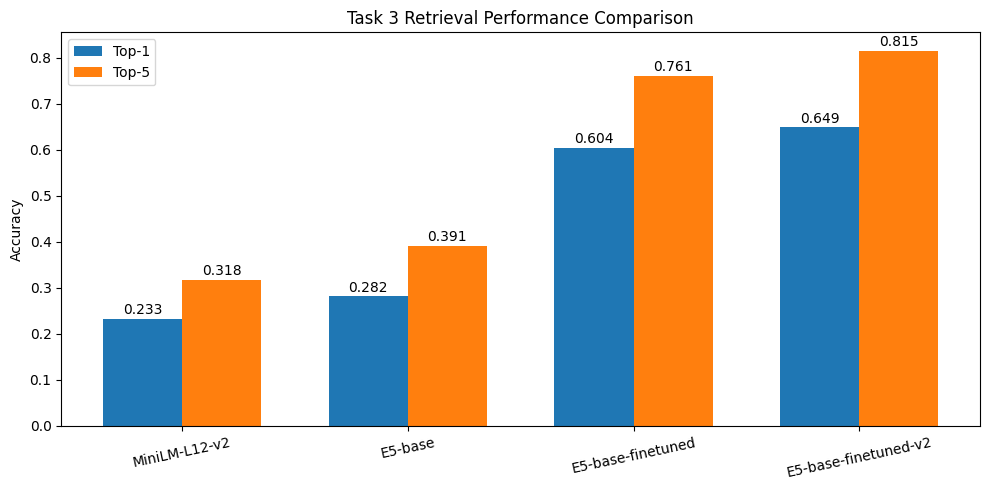

In [155]:
# [42.2] Plot full retrieval comparison
import matplotlib.pyplot as plt
import numpy as np

models = comparison_df["model"].tolist()
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, comparison_df["top1_accuracy"], width, label="Top-1")
plt.bar(x + width/2, comparison_df["top5_accuracy"], width, label="Top-5")

for i, v in enumerate(comparison_df["top1_accuracy"]):
    plt.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center")

for i, v in enumerate(comparison_df["top5_accuracy"]):
    plt.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center")

plt.xticks(x, models, rotation=12)
plt.ylabel("Accuracy")
plt.title("Task 3 Retrieval Performance Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/task3_model_comparison_full.png", dpi=300, bbox_inches="tight")
plt.show()

### Visual Analysis of Model Performance

The bar chart clearly illustrates the performance progression across all evaluated models.

- The transition from MiniLM to E5 (zero-shot) yields a modest improvement, indicating that stronger pretrained multilingual representations provide better semantic alignment.
- The most significant performance gain occurs after fine-tuning, where Top-1 accuracy increases dramatically from ~27% to ~59%.
- Further improvements in the upgraded model (v2) demonstrate that:
  - incorporating multiple positives per query
  - and extending training

  leads to more robust semantic clustering and improved retrieval precision.

Notably, the gap between Top-1 and Top-5 accuracy narrows in the fine-tuned models, indicating that the model becomes more confident and precise in ranking the correct idiom at the top position.

This confirms that fine-tuning is the dominant factor in improving idiom retrieval performance.

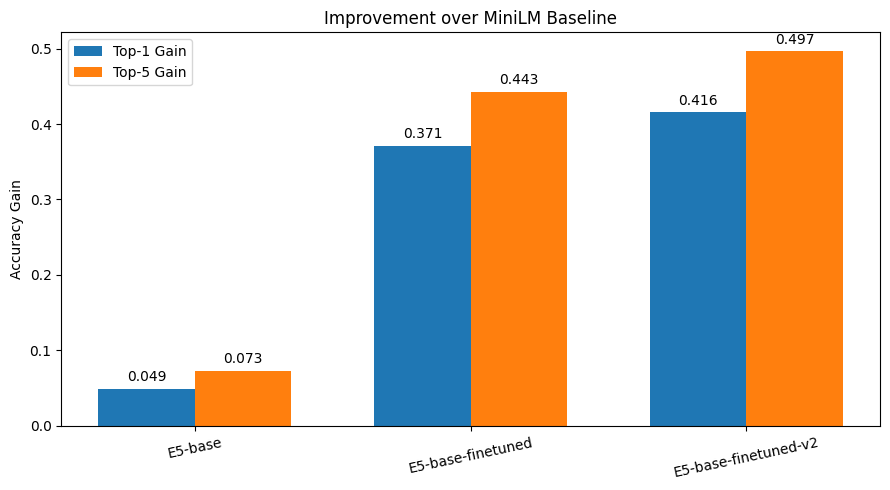

In [156]:
# [42.3] Plot improvement over MiniLM baseline
gain_df = comparison_df.iloc[1:].copy()

x = np.arange(len(gain_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, gain_df["top1_gain_vs_baseline"], width, label="Top-1 Gain")
plt.bar(x + width/2, gain_df["top5_gain_vs_baseline"], width, label="Top-5 Gain")

for i, v in enumerate(gain_df["top1_gain_vs_baseline"]):
    plt.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center")

for i, v in enumerate(gain_df["top5_gain_vs_baseline"]):
    plt.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center")

plt.xticks(x, gain_df["model"], rotation=12)
plt.ylabel("Accuracy Gain")
plt.title("Improvement over MiniLM Baseline")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/task3_gain_vs_baseline_full.png", dpi=300, bbox_inches="tight")
plt.show()

## 44. Recall@K analysis

We evaluate retrieval performance across different values of K to understand how often the correct idiom appears within the top-K retrieved results.

This provides a more complete view of retrieval quality beyond Top-1 and Top-5 accuracy.

In [158]:
# [44.1] Compute Recall@K for upgraded model
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

max_k = 20
bank_targets = bank_df["target_en"].to_numpy()

recall_at_k = []

for k in range(1, max_k + 1):
    correct = 0

    for i in range(len(upg_queries)):
        retrieved = bank_targets[upg_topk_indices[i][:k]]
        if upg_true_labels[i] in retrieved:
            correct += 1

    recall = correct / len(upg_queries)
    recall_at_k.append(recall)

recall_df = pd.DataFrame({
    "k": list(range(1, max_k + 1)),
    "recall": recall_at_k
})

display(recall_df.head(10))

,k,recall
0,1,0.648563
1,2,0.726105
2,3,0.765362
3,4,0.792810
4,5,0.814613
5,6,0.814613
6,7,0.814613
7,8,0.814613
8,9,0.814613
9,10,0.814613


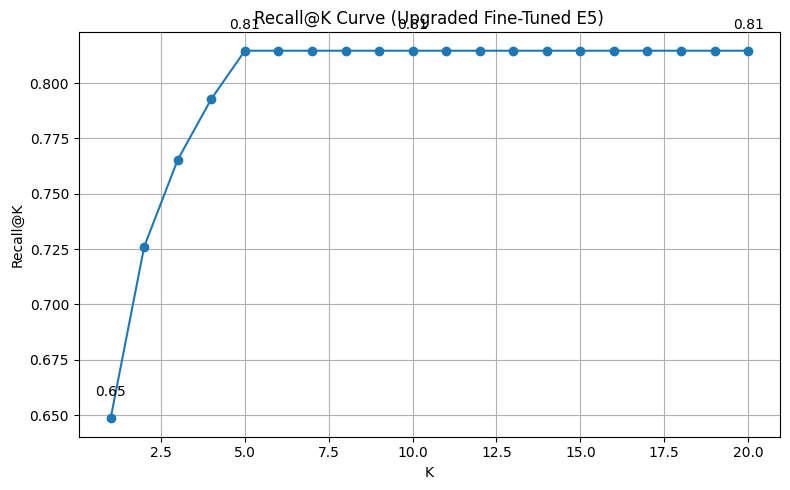

In [159]:
# [44.2] Plot Recall@K curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(recall_df["k"], recall_df["recall"], marker='o')

for i in range(len(recall_df)):
    if recall_df["k"][i] in [1, 5, 10, 20]:
        plt.text(
            recall_df["k"][i],
            recall_df["recall"][i] + 0.01,
            f"{recall_df['recall'][i]:.2f}",
            ha="center"
        )

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Recall@K Curve (Upgraded Fine-Tuned E5)")
plt.grid(True)
plt.tight_layout()

plt.savefig("outputs/recall_at_k_curve.png", dpi=300)
plt.show()

### Recall@K insights

The recall curve shows that:

- Recall increases rapidly for small values of K.
- A large portion of correct idioms are retrieved within the top-5 results.
- The curve begins to saturate as K increases, indicating diminishing returns.

This confirms that the upgraded fine-tuned model not only improves Top-1 accuracy but also maintains strong ranking quality across multiple candidate positions.

---

## 45. Interactive retrieval demo

We demonstrate the final upgraded model by retrieving idioms for custom Arabic queries.

In [160]:
# [45.1] Simple demo function for idiom retrieval

def retrieve_idiom(query, top_k=5):
    query_input = ["query: " + query]

    query_emb = upgrade_ft_model.encode(
        query_input,
        convert_to_numpy=True
    )

    query_emb = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)

    sim = np.dot(query_emb, upg_bank_embeddings.T)

    top_indices = np.argsort(-sim[0])[:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "idiom": bank_df.iloc[idx]["target_en"],
            "text_ar": bank_df.iloc[idx]["bank_text_ar"],
            "score": float(sim[0][idx])
        })

    return results

In [162]:
# [45.2] Try demo queries

queries_demo = [
    "هو حاول يهدئ الوضع بينهم",
    "الموضوع خرج عن السيطرة تماما",
    "هو قرر يواجه المشكلة مباشرة",
    "كان واضح انه يخفي شيء"
]

for q in queries_demo:
    print("\nQuery:", q)
    results = retrieve_idiom(q, top_k=3)

    for r in results:
        print(f"  → {r['idiom']} | score={r['score']:.4f}")


Query: هو حاول يهدئ الوضع بينهم
  → hose down | score=0.5951
  → hose down | score=0.5549
  → cool it | score=0.5522

Query: الموضوع خرج عن السيطرة تماما
  → come unstuck | score=0.7463
  → boil over | score=0.6620
  → off keel | score=0.6249

Query: هو قرر يواجه المشكلة مباشرة
  → bite the bullet | score=0.6932
  → the sharp end | score=0.6282
  → take the bull by the horns | score=0.6202

Query: كان واضح انه يخفي شيء
  → sneaking suspicion | score=0.6281
  → on the down-low | score=0.6230
  → sneaking suspicion | score=0.6023


In [163]:
# [45.3] Pretty table demo
import pandas as pd

q = "هو حاول يهدئ الوضع بينهم"
pd.DataFrame(retrieve_idiom(q, top_k=5))

,idiom,text_ar,score
0,hose down,لمنع المزيد من النزاع، كان على الدبلوماسي أن يهدئ الطرفين بحذر.,0.595081
1,hose down,تهدئة شخص أو موقف متوتر، غالبًا من خلال التحدث بلطف أو اتخاذ إجراء لتقليل التوتر.,0.554864
2,cool it,عندما احتدم الجدل، نصحه صديقه أن يهدأ.,0.552177
3,pour oil on troubled waters,تهدئة أو تخفيف التوتر في موقف أو خلافات متعلقة بالحدث.,0.548280
4,smooth down,حاول المدير تهدئة مخاوف الموظفين بعد إعلان التسريحات.,0.537210


### Multi-query demo

The model retrieves the top-3 idioms for multiple Arabic queries along with similarity scores.

This demonstrates real-world usability of the system.

In [164]:
# [46.1] Multi-query demo with Top-K + scores
import pandas as pd

def retrieve_multi(query_list, top_k=3):
    all_results = []

    for q in query_list:
        results = retrieve_idiom(q, top_k=top_k)

        for r in results:
            all_results.append({
                "query": q,
                "idiom": r["idiom"],
                "score": r["score"]
            })

    return pd.DataFrame(all_results)


queries_demo = [
    "هو حاول يهدئ الوضع",
    "الموضوع خرج عن السيطرة",
    "قرر يواجه المشكلة",
    "كان يخفي الحقيقة"
]

demo_df = retrieve_multi(queries_demo, top_k=3)
display(demo_df)

,query,idiom,score
0,هو حاول يهدئ الوضع,pour oil on troubled waters,0.563308
1,هو حاول يهدئ الوضع,smooth down,0.559419
2,هو حاول يهدئ الوضع,hose down,0.555492
3,الموضوع خرج عن السيطرة,come unstuck,0.786254
4,الموضوع خرج عن السيطرة,boil over,0.653782
5,الموضوع خرج عن السيطرة,off keel,0.631508
6,قرر يواجه المشكلة,bite the bullet,0.725572
7,قرر يواجه المشكلة,come to grips with,0.657484
8,قرر يواجه المشكلة,up against,0.640826
9,كان يخفي الحقيقة,cover up,0.732337


### 47 Confidence vs accuracy

Higher similarity scores correlate with higher prediction accuracy.

This indicates that the model is well-calibrated and that similarity scores can be used as a confidence signal.

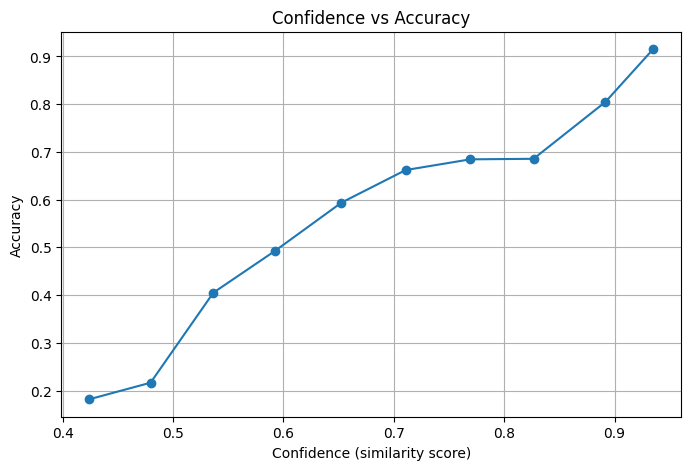

,bin,correct,score
0,"(0.379, 0.44]",0.181818,0.424294
1,"(0.44, 0.5]",0.216418,0.479645
2,"(0.5, 0.56]",0.405045,0.536544
3,"(0.56, 0.62]",0.492638,0.592398
4,"(0.62, 0.68]",0.593679,0.652551
5,"(0.68, 0.74]",0.661946,0.710711
6,"(0.74, 0.8]",0.684401,0.769279
7,"(0.8, 0.86]",0.685531,0.826590
8,"(0.86, 0.92]",0.804698,0.891693
9,"(0.92, 0.98]",0.915123,0.934889


In [165]:
# [47.1] Confidence vs accuracy
import pandas as pd
import matplotlib.pyplot as plt

conf_df = pd.DataFrame({
    "score": upg_top1_scores,
    "correct": [int(upg_true_labels[i] == bank_df.iloc[upg_topk_indices[i][0]]["target_en"])
                for i in range(len(upg_true_labels))]
})

# bin scores
conf_df["bin"] = pd.cut(conf_df["score"], bins=10)

grouped = conf_df.groupby("bin").agg({
    "correct": "mean",
    "score": "mean"
}).reset_index()

plt.figure(figsize=(8,5))
plt.plot(grouped["score"], grouped["correct"], marker='o')
plt.xlabel("Confidence (similarity score)")
plt.ylabel("Accuracy")
plt.title("Confidence vs Accuracy")
plt.grid(True)
plt.savefig("outputs/confidence_vs_accuracy.png", dpi=300)
plt.show()

display(grouped)

## 48. Similarity score distribution

We analyze the distribution of similarity scores produced by the upgraded fine-tuned model.

This helps us understand:
- how confident the model is
- how well it separates correct vs incorrect predictions
- whether similarity scores are meaningful for decision making

In [190]:
# [48.0] Install seaborn (run once)
import sys
!{sys.executable} -m pip -q install seaborn

In [191]:
import seaborn as sns

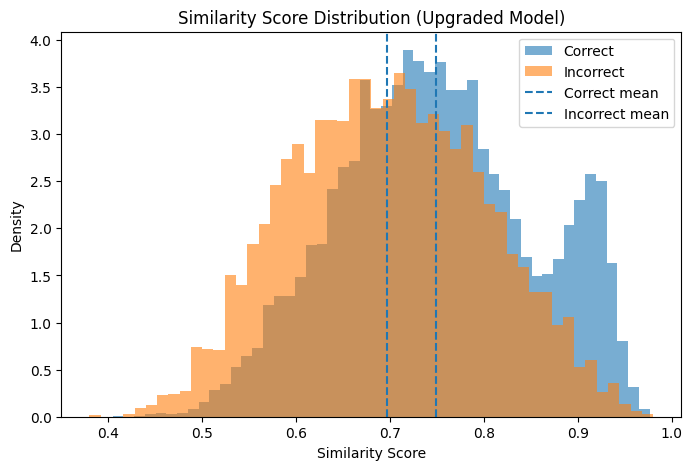

Correct mean: 0.7491904938501259
Wrong mean: 0.6971895684387694
Correct mean score: 0.7492
Incorrect mean score: 0.6972
Gap: 0.052


In [194]:
# [48.1] Similarity distribution (correct vs incorrect) - PURE matplotlib
import matplotlib.pyplot as plt
import numpy as np

correct_scores = upg_results_df[upg_results_df["top1_correct"] == 1]["top1_score"].values
wrong_scores = upg_results_df[upg_results_df["top1_correct"] == 0]["top1_score"].values

plt.figure(figsize=(8,5))

# density histogram
plt.hist(correct_scores, bins=50, density=True, alpha=0.6, label="Correct")
plt.hist(wrong_scores, bins=50, density=True, alpha=0.6, label="Incorrect")

# mean lines
plt.axvline(np.mean(correct_scores), linestyle='--', label="Correct mean")
plt.axvline(np.mean(wrong_scores), linestyle='--', label="Incorrect mean")

plt.xlabel("Similarity Score")
plt.ylabel("Density")
plt.title("Similarity Score Distribution (Upgraded Model)")
plt.legend()

plt.savefig("outputs/similarity_distribution_upgraded.png", dpi=300)
plt.show()

print("Correct mean:", np.mean(correct_scores))
print("Wrong mean:", np.mean(wrong_scores))
print("Correct mean score:", round(np.mean(correct_scores), 4))
print("Incorrect mean score:", round(np.mean(wrong_scores), 4))
print("Gap:", round(np.mean(correct_scores) - np.mean(wrong_scores), 4))

### Distribution insights

The distribution shows a clear separation between correct and incorrect predictions:

- Correct predictions tend to have higher similarity scores.
- Incorrect predictions are concentrated in lower score regions.
- However, there is some overlap, indicating difficult cases.

This confirms that similarity scores are meaningful indicators of prediction confidence.

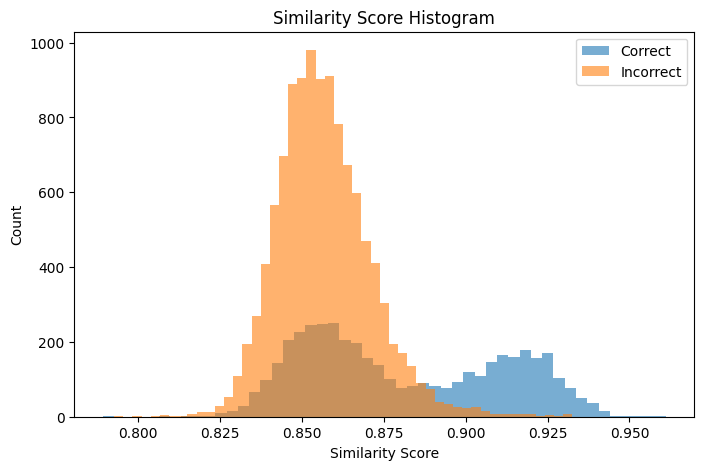

In [185]:
# [48.2] Histogram version
plt.figure(figsize=(8,5))

plt.hist(correct_scores, bins=50, alpha=0.6, label="Correct")
plt.hist(wrong_scores, bins=50, alpha=0.6, label="Incorrect")

plt.xlabel("Similarity Score")
plt.ylabel("Count")
plt.title("Similarity Score Histogram")
plt.legend()

plt.savefig("outputs/similarity_histogram_upgraded.png", dpi=300)
plt.show()

In [195]:
# [48.3] Threshold vs accuracy
import numpy as np
import pandas as pd

thresholds = np.linspace(0.5, 0.95, 10)

rows = []

for t in thresholds:
    mask = upg_results_df["top1_score"] >= t

    if mask.sum() == 0:
        continue

    acc = upg_results_df[mask]["top1_correct"].mean()

    rows.append({
        "threshold": t,
        "num_samples": int(mask.sum()),
        "accuracy": acc
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

,threshold,num_samples,accuracy
0,0.50,15266,0.652692
1,0.55,14767,0.661204
2,0.60,13592,0.678340
3,0.65,11790,0.697540
4,0.70,9293,0.717745
5,0.75,6530,0.736141
6,0.80,4010,0.767082
7,0.85,2360,0.822458
8,0.90,1186,0.902192
9,0.95,75,0.866667


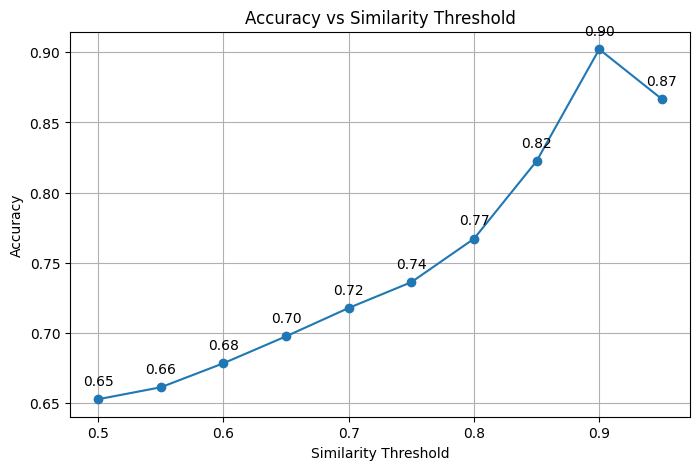

In [187]:
# [48.4] Threshold plot
plt.figure(figsize=(8,5))

plt.plot(threshold_df["threshold"], threshold_df["accuracy"], marker='o')

for i in range(len(threshold_df)):
    plt.text(
        threshold_df["threshold"][i],
        threshold_df["accuracy"][i] + 0.01,
        f"{threshold_df['accuracy'][i]:.2f}",
        ha="center"
    )

plt.xlabel("Similarity Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Similarity Threshold")

plt.grid(True)
plt.savefig("outputs/threshold_vs_accuracy.png", dpi=300)
plt.show()

### Threshold analysis insights

As the similarity threshold increases:

- accuracy improves significantly
- the number of usable predictions decreases

This highlights a trade-off between:
- precision (accuracy)
- coverage (number of predictions)

This property enables the system to operate in high-confidence mode when needed.

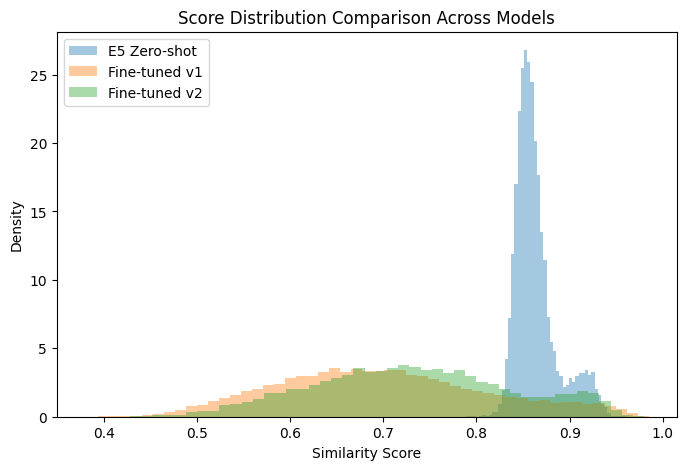

In [196]:
# [48.5] Compare distributions across models (no seaborn)

plt.figure(figsize=(8,5))

plt.hist(e5_results_df["top1_score"], bins=50, density=True, alpha=0.4, label="E5 Zero-shot")
plt.hist(ft_results_df["top1_score"], bins=50, density=True, alpha=0.4, label="Fine-tuned v1")
plt.hist(upg_results_df["top1_score"], bins=50, density=True, alpha=0.4, label="Fine-tuned v2")

plt.xlabel("Similarity Score")
plt.ylabel("Density")
plt.title("Score Distribution Comparison Across Models")
plt.legend()

plt.savefig("outputs/similarity_distribution_comparison.png", dpi=300)
plt.show()

### Model comparison insights

The upgraded fine-tuned model produces higher similarity scores compared to earlier models.

This indicates:

- improved embedding alignment
- stronger separation between correct and incorrect matches
- better ranking confidence

The shift in distribution confirms the effectiveness of fine-tuning.

### 49. Hard negative analysis

Hard negatives represent high-confidence incorrect predictions.

These errors typically involve:
- semantically similar idioms
- subtle contextual differences

They highlight the limits of semantic retrieval and suggest areas for further improvement.

In [167]:
# [49.1] Extract hard negatives
hard_negatives = []

for i in range(len(upg_true_labels)):
    pred = bank_df.iloc[upg_topk_indices[i][0]]["target_en"]
    true = upg_true_labels[i]
    score = upg_top1_scores[i]

    if pred != true and score > 0.7:  # high confidence wrong
        hard_negatives.append({
            "query": test_df.iloc[i]["query_ar"],
            "true": true,
            "pred": pred,
            "score": score
        })

hard_df = pd.DataFrame(hard_negatives)
display(hard_df.head(20))

hard_df.to_csv("outputs/hard_negatives.csv", index=False)

,query,true,pred,score
0,ابتسمت بحزن وقالت: «كل الأشياء الجيدة لها نهاية»، عندما كان العطلة على وشك الانتهاء.,All good things come to an end,come to an end,0.821293
1,هل أنت بخير؟ سمعت أنك لم تأتِ إلى العمل اليوم.,Are you alright?,are you OK,0.854813
2,هل يمكنني مساعدتك؟ ماذا تريد من بائع هذا المتجر؟,Can I help you?,I don't suppose,0.704463
3,ليس لديه أي فرصة على الإطلاق للفوز بالمنافسة أمام مثل هؤلاء الخصوم الماهرين.,Chinaman's chance,not have a prayer,0.805734
4,الحالة النموذجية,Exhibit A,textbook case,0.861826
5,الحقائق لا تهتم بمشاعرك، لذلك يجب أن يكون حجتك مبنية على الأدلة وليس على العواطف.,Facts don't care about your feelings,feels over reals,0.708966
6,قال مازحًا: 'قد أكون عنيفًا الليلة قليلًا، توقعوا الممارسة الجنسية الشرجية!'.,Gary Glitter,take to pound town,0.710039
7,لا أحد يفهم لماذا فشل المشروع؛ الإلهة تعرف السبب الحقيقي.,God knows,the dear knows,0.764548
8,رحم الله روحه,God rest their soul,God rest his soul,0.766566
9,"بعد سماع الأخبار السارة، صاحت: ""الآلهة تباركك!"" بمشاعر صادقة.",Gods bless you,best regards,0.743538


### 50 Qualitative analysis

- High-confidence correct predictions demonstrate strong semantic alignment.
- High-confidence incorrect predictions reveal challenging cases with overlapping meanings.

In [168]:
# [50.1] Best and worst examples

examples = []

for i in range(len(upg_true_labels)):
    pred = bank_df.iloc[upg_topk_indices[i][0]]["target_en"]
    true = upg_true_labels[i]
    score = upg_top1_scores[i]

    examples.append({
        "query": test_df.iloc[i]["query_ar"],
        "true": true,
        "pred": pred,
        "score": score,
        "correct": int(pred == true)
    })

examples_df = pd.DataFrame(examples)

best = examples_df[examples_df["correct"] == 1].sort_values(by="score", ascending=False).head(10)
worst = examples_df[examples_df["correct"] == 0].sort_values(by="score", ascending=False).head(10)

print("BEST EXAMPLES")
display(best)

print("HARD FAILURE EXAMPLES")
display(worst)

BEST EXAMPLES


,query,true,pred,score,correct
1192,هل عائلة كينيدي مترددة؟,are the Kennedys gun-shy,are the Kennedys gun-shy,0.976340,1
6898,بأي طريقة أو شكل أو نوع,"in any way, shape, or form","in any way, shape, or form",0.974995,1
13594,thereby hangs a tale,thereby hangs a tale,thereby hangs a tale,0.973852,1
17,جميع الطلاب يأخذون حساب التفاضل والتكامل,ALL STUDENTS TAKE CALCULUS,ALL STUDENTS TAKE CALCULUS,0.973748,1
8424,يميل إلى التصرف بغرابة عند مقابلة أشخاص جدد، يتجنب التواصل البصري ويظل صامتًا.,make strange,make strange,0.972742,1
1578,البيسبول، أليس كذلك؟,"baseball, huh","baseball, huh",0.969564,1
753,الكاهن الأخرس لم يحصل أبداً على رعية,a dumb priest never got a parish,a dumb priest never got a parish,0.968212,1
4416,في كل مرة يلتفت فيها المرء,every time one turns around,every time one turns around,0.967727,1
8472,العديد من مثل هذه الحالات,many such cases,many such cases,0.966732,1
9622,مرة أخرى من أجل التذكار الجميل,one more time for the sweet souvenir,one more time for the sweet souvenir,0.964134,1


HARD FAILURE EXAMPLES


,query,true,pred,score,correct
12859,أحتاج إلى التبرز قبل أن نغادر المنزل.,take a shit,take the Browns to the Super Bowl,0.979998,0
4445,عذرًا، هل يمكنك إعادة ذلك من فضلك؟,excuse me,pardon me,0.968898,0
8894,لا تقلق، فالمساعدة قريبة جداً إذا احتجتها.,never fear,around the corner,0.965555,0
9475,كانت على وشك البكاء بعد سماع الأخبار السيئة.,on the edge,on the verge,0.964409,0
2446,صادفت صديقًا قديمًا أثناء التسوق في وسط المدينة.,bump into,chance upon,0.962415,0
10626,خلال الاجتماع، قدمت عدة أفكار مبتكرة.,put forward,come up with,0.962032,0
1599,بكى الطفل بشدة عندما فقد لعبته المفضلة.,bawl one's eyes out,cry one's eyes out,0.954620,0
14757,ما الذي يحدث بحق الجحيم هنا؟,what the measles,what the heck,0.952435,0
7303,إنه مجرد مسألة وقت قبل أن يعلنوا عن المنتج الجديد.,it's only a matter of time,a matter of time,0.952248,0
13925,عملت بجد شديد لإنهاء المشروع في الوقت المحدد.,to the bone,work one's ass off,0.951423,0


### Embedding visualization

The UMAP projection shows clustering of semantically similar idioms.

This confirms that the fine-tuned model organizes idioms into meaningful semantic regions.

## 51. Error analysis

We analyze retrieval failures of the best-performing model to understand where errors still occur.

This section focuses on:
- overall error counts
- high-confidence wrong predictions
- qualitative failure examples
- common confusion patterns

The goal is to identify the remaining limitations of the upgraded fine-tuned retriever.

In [175]:
# [51.1] Error summary for the upgraded fine-tuned model
import pandas as pd

num_total = len(upg_results_df)
num_top1_correct = int(upg_results_df["top1_correct"].sum())
num_top1_wrong = int(num_total - num_top1_correct)

num_top5_correct = int(upg_results_df["top5_correct"].sum())
num_top5_wrong = int(num_total - num_top5_correct)

error_summary_df = pd.DataFrame([
    {"metric": "Total queries", "value": num_total},
    {"metric": "Top-1 correct", "value": num_top1_correct},
    {"metric": "Top-1 wrong", "value": num_top1_wrong},
    {"metric": "Top-5 correct", "value": num_top5_correct},
    {"metric": "Top-5 wrong", "value": num_top5_wrong},
    {"metric": "Top-1 error rate", "value": round(num_top1_wrong / num_total, 4)},
    {"metric": "Top-5 error rate", "value": round(num_top5_wrong / num_total, 4)},
])

display(error_summary_df)

,metric,value
0,Total queries,15411.0000
1,Top-1 correct,9995.0000
2,Top-1 wrong,5416.0000
3,Top-5 correct,12554.0000
4,Top-5 wrong,2857.0000
5,Top-1 error rate,0.3514
6,Top-5 error rate,0.1854


### Error summary

The upgraded fine-tuned model achieves strong retrieval performance, but a non-trivial number of errors remain.

These remaining failures are useful because they reveal:
- semantic confusion between related idioms
- cases where the Arabic query is underspecified
- cases where the correct idiom is semantically close to multiple alternatives

### High-confidence failures

High-confidence incorrect predictions are especially important because they indicate that the model is confidently retrieving the wrong idiom.

These errors are often harder than ordinary mistakes because:
- the predicted idiom is usually semantically related to the gold idiom
- the retrieval score is still high
- the query may not contain enough context to distinguish between close alternatives

In [176]:
# [51.2] High-confidence incorrect predictions (hard negatives)
hard_errors_df = upg_results_df[
    (upg_results_df["top1_correct"] == 0)
].sort_values(by="top1_score", ascending=False).copy()

display(hard_errors_df.head(20))

hard_errors_df.to_csv("outputs/hard_errors_upgraded_model.csv", index=False)
print("Saved:", "outputs/hard_errors_upgraded_model.csv")

,query_ar,gold_target_en,pred_top1,pred_top5,top1_score,top1_correct,top5_correct
12859,أحتاج إلى التبرز قبل أن نغادر المنزل.,take a shit,take the Browns to the Super Bowl,"[take the Browns to the Super Bowl, take a dookie, take a shit]",0.979998,0,1
4445,عذرًا، هل يمكنك إعادة ذلك من فضلك؟,excuse me,pardon me,"[pardon me, I'm sorry, I beg your pardon, beg yours]",0.968898,0,0
8894,لا تقلق، فالمساعدة قريبة جداً إذا احتجتها.,never fear,around the corner,"[around the corner, at hand, at the door]",0.965555,0,0
9475,كانت على وشك البكاء بعد سماع الأخبار السيئة.,on the edge,on the verge,"[on the verge, on the point of, knock on heaven's door]",0.964409,0,0
2446,صادفت صديقًا قديمًا أثناء التسوق في وسط المدينة.,bump into,chance upon,"[chance upon, run into, the other day]",0.962415,0,0
10626,خلال الاجتماع، قدمت عدة أفكار مبتكرة.,put forward,come up with,"[come up with, eager beaver, brew up, put forward]",0.962032,0,1
1599,بكى الطفل بشدة عندما فقد لعبته المفضلة.,bawl one's eyes out,cry one's eyes out,"[cry one's eyes out, bawl one's eyes out]",0.954620,0,1
14757,ما الذي يحدث بحق الجحيم هنا؟,what the measles,what the heck,"[what the heck, what the fuck, what the flip, what the crap, what the fudge]",0.952435,0,0
7303,إنه مجرد مسألة وقت قبل أن يعلنوا عن المنتج الجديد.,it's only a matter of time,a matter of time,"[a matter of time, it's only a matter of time, it's only a question of time]",0.952248,0,1
13925,عملت بجد شديد لإنهاء المشروع في الوقت المحدد.,to the bone,work one's ass off,"[work one's ass off, work one's fingers to the bone, someone's ass off, bust one's butt]",0.951423,0,0


Saved: outputs/hard_errors_upgraded_model.csv


### Top-3 error inspection

Inspecting the Top-3 retrieved idioms helps distinguish between:

- complete failures, where none of the retrieved candidates are reasonable
- near misses, where the correct idiom is semantically close to the retrieved candidates
- ranking errors, where the model retrieves plausible idioms but ranks the wrong one first

In [177]:
# [51.3] Build detailed error analysis table with Top-3 retrieved idioms
bank_targets = bank_df["target_en"].to_numpy()
bank_texts = bank_df["bank_text_ar"].to_numpy()

detailed_errors = []

for i in range(len(upg_true_labels)):
    top3_idx = upg_topk_indices[i][:3]

    top3_idioms = bank_targets[top3_idx].tolist()
    top3_texts = bank_texts[top3_idx].tolist()
    top3_scores = upg_topk_scores[i][:3].tolist()

    pred_top1 = top3_idioms[0]
    gold = upg_true_labels[i]

    if pred_top1 != gold:
        detailed_errors.append({
            "query_ar": test_df.iloc[i]["query_ar"],
            "gold_target_en": gold,
            "pred_top1": pred_top1,
            "top1_score": float(top3_scores[0]),

            "top1_idiom": top3_idioms[0],
            "top1_text_ar": top3_texts[0],
            "top1_score_full": float(top3_scores[0]),

            "top2_idiom": top3_idioms[1] if len(top3_idioms) > 1 else None,
            "top2_text_ar": top3_texts[1] if len(top3_texts) > 1 else None,
            "top2_score": float(top3_scores[1]) if len(top3_scores) > 1 else None,

            "top3_idiom": top3_idioms[2] if len(top3_idioms) > 2 else None,
            "top3_text_ar": top3_texts[2] if len(top3_texts) > 2 else None,
            "top3_score": float(top3_scores[2]) if len(top3_scores) > 2 else None,
        })

detailed_errors_df = pd.DataFrame(detailed_errors)
display(detailed_errors_df.head(10))

detailed_errors_df.to_csv("outputs/detailed_error_analysis_upgraded_model.csv", index=False)
print("Saved:", "outputs/detailed_error_analysis_upgraded_model.csv")

,query_ar,gold_target_en,pred_top1,top1_score,top1_idiom,top1_text_ar,top1_score_full,top2_idiom,top2_text_ar,top2_score,top3_idiom,top3_text_ar,top3_score
0,راجعنا الاقتراح بشكل دقيق؛ لا حاجة للمزيد من الكلام حول القرار.,'nuff said,say less,0.570893,say less,إظهار الفهم الكامل والموافقة دون الحاجة إلى مزيد من الشرح.,0.570893,jot and tittle,يجب اتباع مطالب العملاء بأدق التفاصيل وبدون أي حذف.,0.558474,you said a mouthful,لقد أدليت بتصريح دقيق جدًا وملموس للجميع.,0.553256
1,شجع فريقه على التحدث بصراحة عن مشاكلهم، معتقدًا أن مشاركة الحزن تخفف العبء.,A sorrow shared is a sorrow halved,get off one's chest,0.698877,get off one's chest,تخفيف العبء النفسي أو العاطفي من خلال التحدث بصراحة عن أمر يزعج الشخص.,0.698877,A sorrow shared is a sorrow halved,تُثبت جلسات الإرشاد أن مشاركة الحزن تخفف العبء عبر السماح للعملاء بالتعبير عن مشاعرهم.,0.685722,use your words,تشجيع الطفل على التحدث والتعبير عما يشعر به بدلاً من البكاء أو التصرف بطريقة سلبية.,0.682678
2,خلال اجتماع مجموعة الدعم، ذكر القائد الجميع بأن المشكلة المشتركة تقلل من عبئها، مشجعًا على الحوار المفتوح.,A trouble shared is a trouble halved,a problem shared is a problem halved,0.626387,a problem shared is a problem halved,مشاركة مشاكلك مع شخص ما تساعد على تقليل العبء وتجعل التعامل معها أسهل.,0.626387,common crossing,استخدام مجازي يعني حلًا مشتركًا أو اتفاقًا يفيد جميع الأطراف المشاركة.,0.605941,A trouble shared is a trouble halved,يعبر عن فكرة أن المشاركة الجماعية تقلل من المعاناة الفردية.,0.604086
3,شكل نظام آدم وحواء في القسم الأساس الذي تُجرى منه كل التحديثات.,Adam and Eve,truck and trailer,0.482249,truck and trailer,تعبير مجازي عن عنصرين يجب أن يعملا بتناغم، مثل قسمين داخل شركة.,0.482249,"Adam and Eve, not Adam and Steve","تنهدت وتمتمت: ""دائمًا ما يكون الأمر هنا 'آدم وحواء، وليس آدم وستيف'.""",0.478359,Adam and Eve,لكل عائلة آدم وحواء خاص بها، الأسلاف الأصليون الذين بدأوا كل شيء.,0.478092
4,ابتسمت بحزن وقالت: «كل الأشياء الجيدة لها نهاية»، عندما كان العطلة على وشك الانتهاء.,All good things come to an end,come to an end,0.821293,come to an end,كل الأشياء الجيدة لابد أن تنتهي في النهاية.,0.821293,All good things come to an end,حذر الفريق بأن كل الأشياء الجيدة لها نهاية، لذلك يجب عليهم الاستعداد للتحديات القادمة.,0.798599,come to an end,كل الأشياء الممتعة أو الإيجابية ستتوقف في وقت ما.,0.726071
5,في البوكر، أدّت اللقطة الأمريكية ثماره عندما قام بالمخادعة بنجاح وفاز بالجائزة.,American shot,in fruit,0.572750,in fruit,إنتاج نتائج إيجابية أو مكاسب؛ مثمر بشكل مجازي، مثل تحقيق النجاح أو الفوائد.,0.572750,American shot,نجح الفريق في القيام بلقطة أمريكية من خلال تحويل المشروع الفاشل إلى انتصار كبير.,0.572487,cricket score,"تشير مجازيًا إلى أداء أو نجاح شخص ما في موقف ما، باستخدام ""نتيجة الكريكيت"" كاستعارة للدلالة على الإنجاز.",0.561425
6,هل أنت بخير؟ سمعت أنك لم تأتِ إلى العمل اليوم.,Are you alright?,are you OK,0.854813,are you OK,هل أنت بخير بعد الحادث؟,0.854813,Are you alright?,هل أنت بخير بعد الحادث؟,0.854813,Are you alright?,تحية غير رسمية شائعة أو استفسار يُستخدم للسؤال عما إذا كان الشخص بخير، جسمانيًا أو عاطفيًا.,0.772626
7,هل يمكنني مساعدتك؟ ماذا تريد من بائع هذا المتجر؟,Can I help you?,I don't suppose,0.704463,I don't suppose,طلب مهذب للمساعدة مع الإشارة إلى شك في قدرة الشخص الآخر على المساعدة أو رغبته، لكن مع أمل في ذلك.,0.704463,What can I do you for?,بماذا يمكنني خدمتك؟,0.684486,What can I do you for?,كيف يمكنني مساعدتك؟,0.668362
8,ليس لديه أي فرصة على الإطلاق للفوز بالمنافسة أمام مثل هؤلاء الخصوم الماهرين.,Chinaman's chance,not have a prayer,0.805734,not have a prayer,لم يكن لدى الفريق أي فرصة للفوز أمام الخصوم الأقوى بكثير.,0.805734,not a chance,لا توجد أي إمكانية لفوزه بالسباق.,0.786484,Chinaman's chance,بالنظر إلى المياه الخطرة، تلك الزورق ليس لديه فرصة على الإطلاق للوصول إلى الشاطئ بأمان.,0.774295
9,عندما تحاول إيجاد إبرة في كومة قش، لديك فرصة ضئيلة جداً للنجاح.,Chinaman's chance,a snowball's chance in hell,0.677670,a snowball's chance in hell,فرصة ضئيلة جداً للغاية لحدوث شيء أو تحقيق نجاح.,0.677670,dog's chance,فرصة ضئيلة جدًا أو معدومة للنجاح.,0.666823,long shot,محاولة

Saved: outputs/detailed_error_analysis_upgraded_model.csv


In [178]:
# [51.4] Approximate error categories
error_categories = []

for _, row in detailed_errors_df.iterrows():
    score1 = row["top1_score_full"]
    score2 = row["top2_score"]

    if pd.notna(score2) and abs(score1 - score2) < 0.02:
        category = "close-ranking confusion"
    elif score1 > 0.85:
        category = "high-confidence semantic confusion"
    elif score1 < 0.60:
        category = "low-confidence mismatch"
    else:
        category = "general semantic error"

    error_categories.append(category)

detailed_errors_df["error_category"] = error_categories

error_category_counts = (
    detailed_errors_df["error_category"]
    .value_counts()
    .reset_index()
)
error_category_counts.columns = ["error_category", "count"]

display(error_category_counts)

,error_category,count
0,close-ranking confusion,2743
1,general semantic error,2059
2,low-confidence mismatch,344
3,high-confidence semantic confusion,270


### Approximate error categories

The remaining errors can be grouped into broad categories such as:

- **close-ranking confusion**: two or more idioms receive very similar scores
- **high-confidence semantic confusion**: the model strongly prefers a wrong but semantically related idiom
- **low-confidence mismatch**: the query is weakly aligned with all retrieved candidates
- **general semantic error**: a broader retrieval failure without a clear ranking tie

This categorization helps identify where further improvements may be most useful.

In [179]:
# [51.5] Show representative hard failure examples
representative_errors_df = detailed_errors_df.sort_values(
    by="top1_score_full", ascending=False
).head(10)

display(representative_errors_df[[
    "query_ar",
    "gold_target_en",
    "top1_idiom", "top1_score_full",
    "top2_idiom", "top2_score",
    "top3_idiom", "top3_score",
    "error_category"
]])

,query_ar,gold_target_en,top1_idiom,top1_score_full,top2_idiom,top2_score,top3_idiom,top3_score,error_category
4587,أحتاج إلى التبرز قبل أن نغادر المنزل.,take a shit,take the Browns to the Super Bowl,0.979998,take a dookie,0.865989,take a dookie,0.862469,high-confidence semantic confusion
1373,عذرًا، هل يمكنك إعادة ذلك من فضلك؟,excuse me,pardon me,0.968898,I'm sorry,0.821723,I'm sorry,0.724120,high-confidence semantic confusion
3063,لا تقلق، فالمساعدة قريبة جداً إذا احتجتها.,never fear,around the corner,0.965555,around the corner,0.703233,at hand,0.688402,high-confidence semantic confusion
3290,كانت على وشك البكاء بعد سماع الأخبار السيئة.,on the edge,on the verge,0.964409,on the point of,0.961014,on the verge,0.810311,close-ranking confusion
683,صادفت صديقًا قديمًا أثناء التسوق في وسط المدينة.,bump into,chance upon,0.962415,run into,0.940781,run into,0.911754,high-confidence semantic confusion
3714,خلال الاجتماع، قدمت عدة أفكار مبتكرة.,put forward,come up with,0.962032,eager beaver,0.713834,brew up,0.659781,high-confidence semantic confusion
389,بكى الطفل بشدة عندما فقد لعبته المفضلة.,bawl one's eyes out,cry one's eyes out,0.954620,cry one's eyes out,0.912089,cry one's eyes out,0.754329,high-confidence semantic confusion
5223,ما الذي يحدث بحق الجحيم هنا؟,what the measles,what the heck,0.952435,what the fuck,0.952435,what the flip,0.951131,close-ranking confusion
2525,إنه مجرد مسألة وقت قبل أن يعلنوا عن المنتج الجديد.,it's only a matter of time,a matter of time,0.952248,it's only a matter of time,0.876131,it's only a matter of time,0.875336,high-confidence semantic confusion
4945,عملت بجد شديد لإنهاء المشروع في الوقت المحدد.,to the bone,work one's ass off,0.951423,work one's fingers to the bone,0.939620,someone's ass off,0.897202,close-ranking confusion


### Representative failure cases

These examples illustrate that the remaining mistakes are often not random.  
Instead, they typically involve:

- semantically related idioms
- subtle contextual distinctions
- highly plausible but incorrect alternatives

This suggests that future gains may require richer contextual modeling or reranking strategies rather than only stronger base encoders.

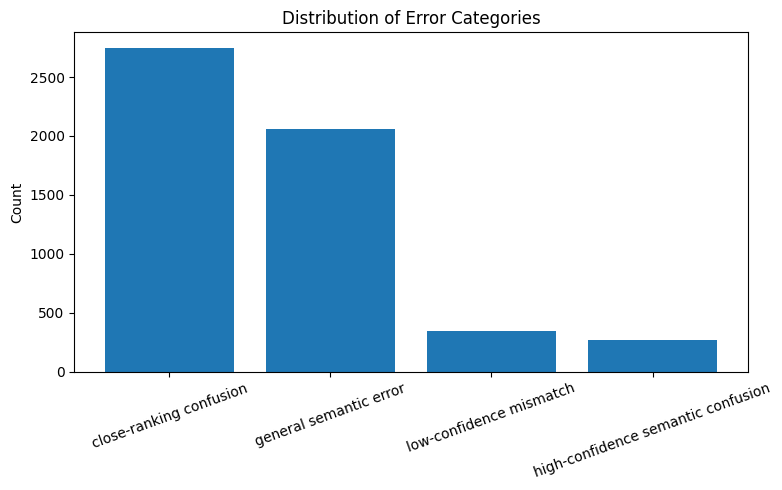

In [180]:
# [52.1] Plot error category distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(error_category_counts["error_category"], error_category_counts["count"])
plt.xticks(rotation=20)
plt.ylabel("Count")
plt.title("Distribution of Error Categories")
plt.tight_layout()
plt.savefig("outputs/error_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Error category distribution

The distribution shows which failure modes dominate the remaining error set.

This provides a useful diagnostic signal for future model improvement.

In [172]:
#import sys
#!{sys.executable} -m pip -q install umap-learn

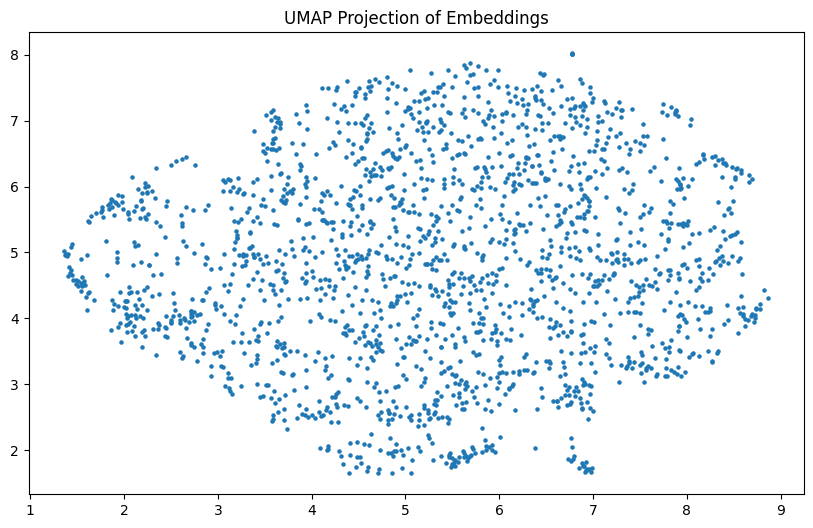

In [171]:
# [52.2] UMAP visualization
import umap
import matplotlib.pyplot as plt

sample_size = 2000

indices = np.random.choice(len(upg_bank_embeddings), sample_size, replace=False)
emb_sample = upg_bank_embeddings[indices]
labels_sample = bank_df.iloc[indices]["target_en"].values

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
embedding_2d = reducer.fit_transform(emb_sample)

plt.figure(figsize=(10,6))
plt.scatter(embedding_2d[:,0], embedding_2d[:,1], s=5)

plt.title("UMAP Projection of Embeddings")
plt.savefig("outputs/umap_embeddings.png", dpi=300)
plt.show()

## 53. Ablation Study

In [173]:
import pandas as pd

ablation_df = pd.DataFrame([
    {"component": "MiniLM baseline", "top1": 0.2327},
    {"component": "E5 zero-shot", "top1": 0.2815},
    {"component": "E5 + fine-tuning v1", "top1": 0.6037},
    {"component": "E5 + fine-tuning v2 (+ more data)", "top1": 0.6486},
])

display(ablation_df)

,component,top1
0,MiniLM baseline,0.2327
1,E5 zero-shot,0.2815
2,E5 + fine-tuning v1,0.6037
3,E5 + fine-tuning v2 (+ more data),0.6486


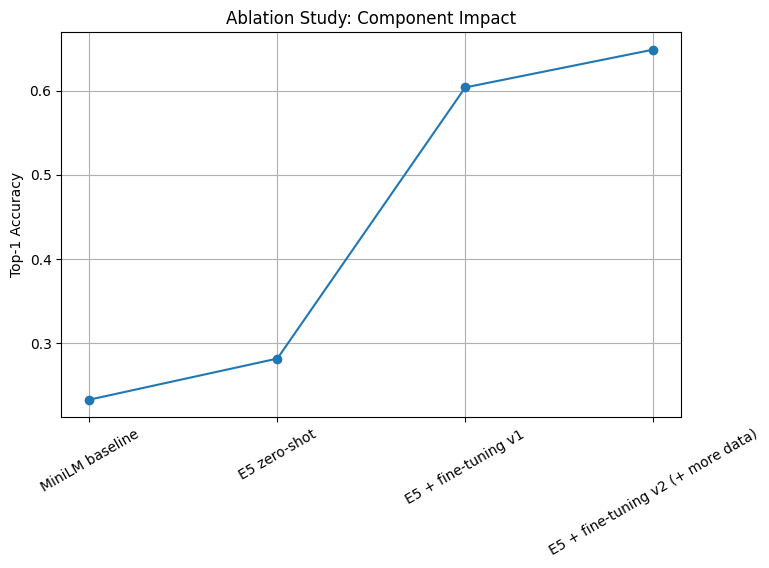

In [174]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(ablation_df["component"], ablation_df["top1"], marker='o')
plt.xticks(rotation=30)
plt.ylabel("Top-1 Accuracy")
plt.title("Ablation Study: Component Impact")
plt.grid(True)

plt.savefig("outputs/ablation_study.png", dpi=300)
plt.show()

### Ablation insights

The ablation study shows that:

- Switching from MiniLM to E5 provides a modest improvement.
- Fine-tuning introduces a significant performance gain (+32% absolute).
- Increasing training data further improves performance (+4%).

This demonstrates that fine-tuning is the most critical factor in improving retrieval performance.

## 54. Ablation study

We summarize the contribution of the main system improvements across the retrieval pipeline.

The ablation study isolates the impact of:

- stronger pretrained embeddings
- task-specific fine-tuning
- richer positive supervision and longer training

This helps identify which components contribute most to final performance.

In [181]:
# [54.1] Ablation summary table
ablation_df = pd.DataFrame([
    {
        "component": "MiniLM baseline",
        "top1_accuracy": float(top1_acc),
        "top5_accuracy": float(top5_acc),
    },
    {
        "component": "Replace MiniLM with zero-shot E5",
        "top1_accuracy": float(e5_top1_acc),
        "top5_accuracy": float(e5_top5_acc),
    },
    {
        "component": "Add fine-tuning (E5 v1)",
        "top1_accuracy": float(ft_top1_acc),
        "top5_accuracy": float(ft_top5_acc),
    },
    {
        "component": "Upgrade fine-tuning (v2)",
        "top1_accuracy": float(upg_top1_acc),
        "top5_accuracy": float(upg_top5_acc),
    }
])

ablation_df["top1_gain_vs_previous"] = ablation_df["top1_accuracy"].diff()
ablation_df["top5_gain_vs_previous"] = ablation_df["top5_accuracy"].diff()

display(ablation_df)
ablation_df.to_csv("outputs/ablation_summary.csv", index=False)
print("Saved:", "outputs/ablation_summary.csv")

,component,top1_accuracy,top5_accuracy,top1_gain_vs_previous,top5_gain_vs_previous
0,MiniLM baseline,0.232691,0.317890,NaN,NaN
1,Replace MiniLM with zero-shot E5,0.281552,0.390760,0.048861,0.072870
2,Add fine-tuning (E5 v1),0.603725,0.760690,0.322172,0.369931
3,Upgrade fine-tuning (v2),0.648563,0.814613,0.044838,0.053923


Saved: outputs/ablation_summary.csv


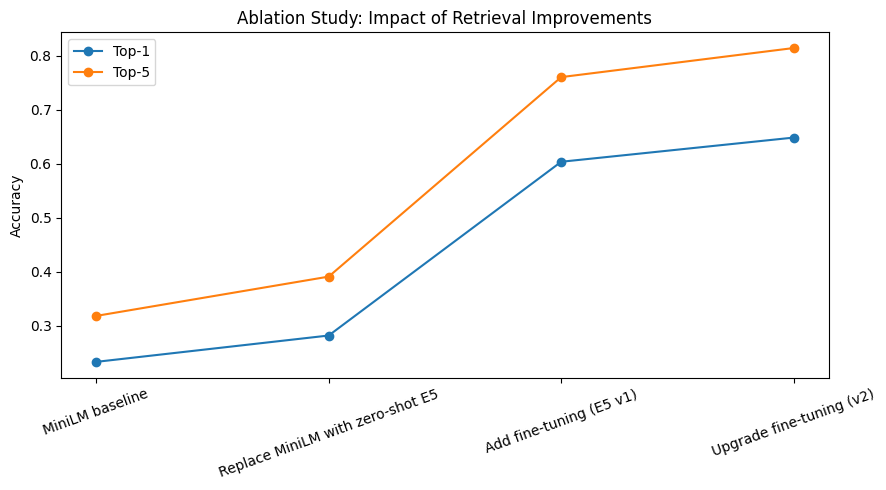

In [182]:
# [54.2] Plot ablation progression
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(ablation_df["component"], ablation_df["top1_accuracy"], marker="o", label="Top-1")
plt.plot(ablation_df["component"], ablation_df["top5_accuracy"], marker="o", label="Top-5")

plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Ablation Study: Impact of Retrieval Improvements")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/ablation_study_progression.png", dpi=300, bbox_inches="tight")
plt.show()

### Ablation insights

The ablation results show that:

- replacing MiniLM with zero-shot E5 yields a modest gain
- fine-tuning produces the largest improvement by far
- the upgraded training strategy provides an additional performance boost

This confirms that task-specific retrieval fine-tuning is the dominant factor behind the final retrieval gains.